## Project 1: World Progress

In this project, you'll explore data from Gapminder.org, a website dedicated to providing a fact-based view of the world and how it has changed. That site includes several data visualizations and presentations, but also publishes the raw data that we will use in this project to recreate and extend some of their most famous visualizations.

The Gapminder website collects data from many sources and compiles them into tables that describe many countries around the world. All of the data they aggregate are published in the Systema Globalis. Their goal is "to compile all public statistics; Social, Economic and Environmental; into a comparable total dataset." All data sets in this project are copied directly from the Systema Globalis without any changes.

https://www.gapminder.org/data/

##Global Population Growth

The global population of humans reached 1 billion around 1800, 3 billion around 1960, and 7 billion around 2011. The potential impact of exponential population growth has concerned scientists, economists, and politicians alike.

The UN Population Division estimates that the world population will likely continue to grow throughout the 21st century, but at a slower rate, perhaps reaching 11 billion by 2100. However, the UN does not rule out scenarios of more extreme growth.

In this section, we will examine some of the factors that influence population growth and how they are changing around the world.

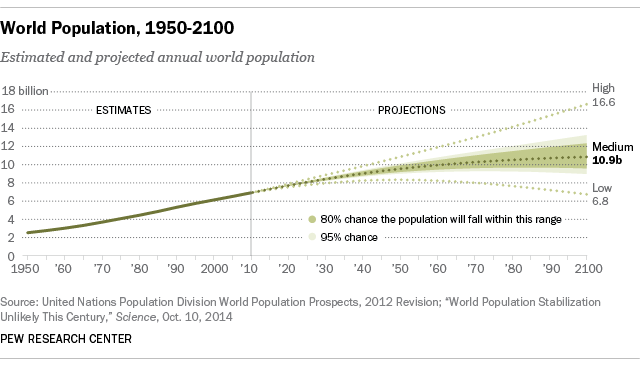

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files
from pandas import DataFrame
from pandas import Series
import seaborn as sns

Bangladesh

In the population table, the geo column contains three-letter codes established by the International Organization for Standardization (ISO) in the Alpha-3 standard. We will begin by taking a close look at Bangladesh. Inspect the standard to find the 3-letter code for Bangladesh.

https://en.wikipedia.org/wiki/ISO_3166-1_alpha-3#Current_codes

### Question 1.
Create a table called b_pop that has two columns labeled time and population_total. The first column should contain the years from 1970 through 2015 (including both 1970 and 2015) and the second should contain the population of Bangladesh in each of those years.

In [ ]:
pop = pd.read_csv('pop.csv')
b_pop = pop[pop['country'] == 'Bangladesh'].T
b_pop = b_pop.iloc[1:] #Remove the country name
b_pop.columns = ['Bangladesh'] #Rename the column
b_pop.index.name = 'Year' #Rename the index
print(b_pop)

     Bangladesh
Year           
1800      19.2M
1801      19.2M
1802      19.3M
1803      19.3M
1804      19.3M
...         ...
2096       213M
2097       212M
2098       211M
2099       210M
2100       209M

[301 rows x 1 columns]


Create a table called b_five that has the population of Bangladesh every five years. At a glance, it appears that the population of Bangladesh has been growing quickly indeed!

In [ ]:
b_five = b_pop[b_pop.index.map(lambda x: int(x) % 5 == 0)]
b_five

,Bangladesh
Year,
1800,19.2M
1805,19.4M
1810,19.6M
1815,19.8M
1820,20.1M
...,...
2080,224M
2085,222M
2090,218M


### Question 2.

Create a table called b_five_growth that includes three columns, time, population_total, and annual_growth. There should be one row for every five years from 1970 through 2010 (but not 2015). The first two columns are the same as b_five. The third column is the annual growth rate for each five-year period. For example, the annual growth rate for 1975 is the yearly exponential growth rate that describes the total growth from 1975 to 1980 when applied 5 times.

Hint: Only your b_five_growth table will be scored for correctness; the other names are suggestions that you are welcome to use, change, or delete.

In [ ]:
b_five_filtered = b_five[(b_five.index >= '1970') & (b_five.index <= '2010')]
b_five_filtered['Bangladesh'] = b_five_filtered['Bangladesh'].str.replace('M', '').astype(float) * 1000000
b_five_filtered['Annual Growth Rate'] = b_five_filtered['Bangladesh'].pct_change() * 100
b_five_filtered['Annual Growth Rate'] = b_five_filtered['Annual Growth Rate']/5
b_five_filtered

<ipython-input-5-c77b77d02a5f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_five_filtered['Bangladesh'] = b_five_filtered['Bangladesh'].str.replace('M', '').astype(float) * 1000000
<ipython-input-5-c77b77d02a5f>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b_five_filtered['Annual Growth Rate'] = b_five_filtered['Bangladesh'].pct_change() * 100
<ipython-input-5-c77b77d02a5f>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col

,Bangladesh,Annual Growth Rate
Year,,
1970,69100000.0,NaN
1975,77900000.0,2.547033
1980,88000000.0,2.593068
1985,100000000.0,2.727273
1990,112000000.0,2.400000
1995,123000000.0,1.964286
2000,135000000.0,1.951220
2005,145000000.0,1.481481
2010,152000000.0,0.965517


While the population has grown every five years since 1970, the annual growth rate decreased dramatically from 1985 to 2005. Let's look at some other information in order to develop a possible explanation. Load three additional tables of measurements about countries over time.


*   life_expectancy.csv
*   child_mortality.csv
*   fertility.csv





In [ ]:
lex = pd.read_csv('lex.csv')
child_mortality = pd.read_csv('child_mortality.csv')
fertility = pd.read_csv('fertility.csv')

The life_expectancy table contains a statistic that is often used to measure how long people live, called life expectancy at birth. This number, for a country in a given year, does not measure how long babies born in that year are expected to live. Instead, it measures how long someone would live, on average, if the mortality conditions in that year persisted throughout their lifetime. These "mortality conditions" describe what fraction of people at each age survived the year. So, it is a way of measuring the proportion of people that are staying alive, aggregated over different age groups in the population.

### Question 3.

Perhaps population is growing more slowly because people aren't living as long. Use the life_expectancy table to draw a line graph with the years 1970 and later on the horizontal axis that shows how the life expectancy at birth has changed in Bangladesh.

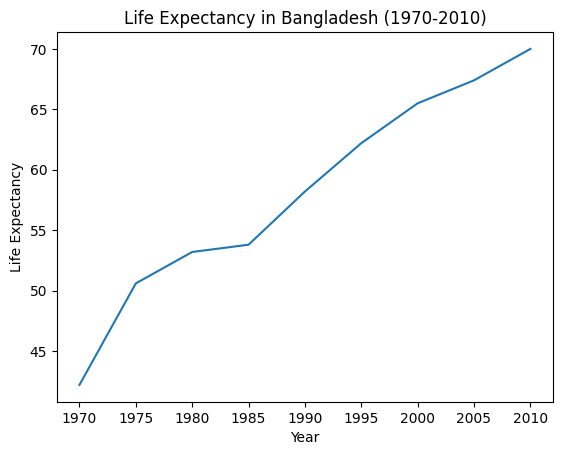

In [ ]:
bangladesh_data = lex[lex['country'] == 'Bangladesh']
years = range(1970, 2011, 5)
life_expectancy = bangladesh_data[list(map(str, years))].values.flatten()
plt.plot(years, life_expectancy)
plt.xlabel('Year')
plt.ylabel('Life Expectancy')
plt.title('Life Expectancy in Bangladesh (1970-2010)')
plt.xticks(years)  # Show every 5 years on x-axis
plt.show()

### Question 4.

Does the graph above help directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not? What happened in Bangladesh in 1991, and does that event explain the change in population growth rate?

The above graph does not give a reason for why the population growth rate decreased from 1985-2010. This is because there is no direct correlation between the two that can be observed. During 1991 in Bangladesh, there was a confounding factor which was a devastating cyclone that hit Bangladesh. This cause over 140,000 deaths and destroyed countless homes. Because of this, people had lost their families and homes which led to a fall in the GDP. Because of this, people could not support a family which could have lead to a fall in the population growth rate during this time.

The graph shows that as the years progress, people live longer. This is most likely a result of the fact that as people tend to live longer they give less importance to reproduction and hence procreate less



The fertility table contains a statistic that is often used to measure how many babies are being born, the total fertility rate. This number describes the number of children a woman would have in her lifetime, on average, if the current rates of birth by age of the mother persisted throughout her child bearing years, assuming she survived through age 49.

### Question 5.

Write a function fertility_over_time that takes the Alpha-3 code of a country and a start year. It returns a two-column table with labels "Year" and "Children per woman" that can be used to generate a line chart of the country's fertility rate each year, starting at the start year. The plot should include the start year and all later years that appear in the fertility table.

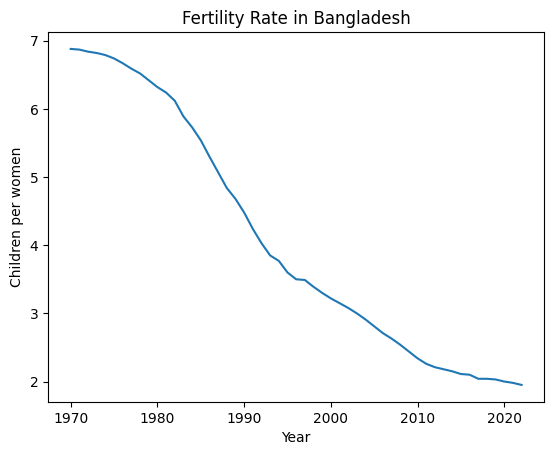

In [ ]:
def fertility_over_time(country, start_year):
    country_data = fertility[fertility['country'] == country]
    # Get the years (column names):
    years = [int(col) for col in country_data.columns if col.isdigit() and int(col) >= start_year]
    # Extract the fertility rate values:
    fertility_rates = country_data[list(map(str, years))].values.flatten()
    # Create the table:
    table = pd.DataFrame({'Year': years, 'Children per women': fertility_rates})
    return table

table = fertility_over_time('Bangladesh', 1970)
# print(table)
# Create the line chart:
plt.plot(table['Year'], table['Children per women'])
plt.xlabel('Year')
plt.ylabel('Children per women')
plt.title('Fertility Rate in Bangladesh')
plt.show()

Then, in the next cell, call your fertility_over_time function on the Alpha-3 code for Bangladesh and the year 1970 in order to plot how Bangladesh's fertility rate has changed since 1970. Note that the function fertility_over_time should not return the plot itself.

### Question 6.

Does the graph above help directly explain why the population growth rate decreased from 1985 to 2010 in Bangladesh? Why or why not?

Yes, the above graph does explain why the population growth decreased from 1985 to 2010 in Bangladesh. During that time period we can see that the fertility rate in Bangladesh reduced which means that women are not producing as many children as before. This is one of the key factors  which leads to a fall in the population growth rate but, we have no reason to explain why the fertility fell in Bangladesh during that time period.

It has been observed that lower fertility rates are often associated with lower child mortality rates. The link has been attributed to family planning: if parents can expect that their children will all survive into adulthood, then they will choose to have fewer children. We can see if this association is evident in Bangladesh by plotting the relationship between total fertility rate and child mortality rate per 1000 children.

### Question 7.

Using both the fertility and child_mortality tables, draw a scatter diagram with one point for each year, starting with 1970, that has Bangladesh's total fertility on the horizontal axis and its child mortality on the vertical axis.

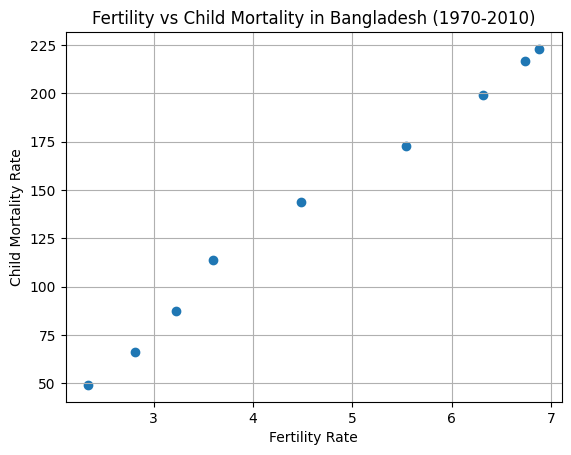

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
fertility = pd.read_csv('fertility.csv', index_col=0)
child_mortality = pd.read_csv('child_mortality.csv', index_col=0)
years = range(1970, 2011, 5)
bangladesh_fertility = fertility.loc['Bangladesh', [str(year) for year in years]]
bangladesh_mortality = child_mortality.loc['Bangladesh', [str(year) for year in years]]
plt.scatter(bangladesh_fertility, bangladesh_mortality)
plt.xlabel('Fertility Rate')
plt.ylabel('Child Mortality Rate')
plt.title('Fertility vs Child Mortality in Bangladesh (1970-2010)')
plt.grid(True)
plt.show()

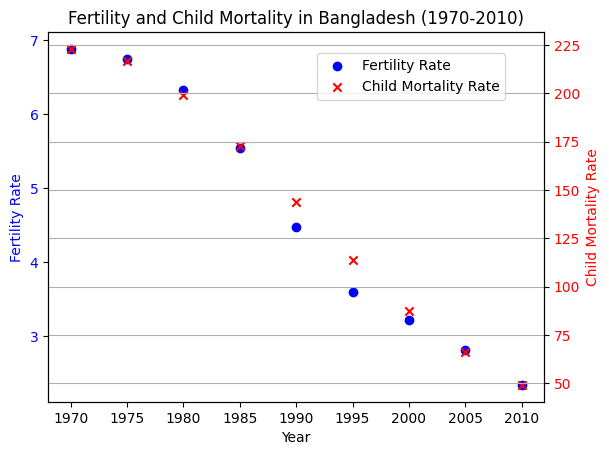

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV files
fertility = pd.read_csv('fertility.csv', index_col=0)
child_mortality = pd.read_csv('child_mortality.csv', index_col=0)

# Select data for Bangladesh and specific years
years = range(1970, 2011, 5)
bangladesh_fertility = fertility.loc['Bangladesh', [str(year) for year in years]]
bangladesh_mortality = child_mortality.loc['Bangladesh', [str(year) for year in years]]

# Create the scatter plot
fig, ax1 = plt.subplots()

# Plot fertility rate on the primary y-axis
ax1.scatter(years, bangladesh_fertility, label='Fertility Rate', marker='o', color='blue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Fertility Rate', color='blue')
ax1.tick_params('y', labelcolor='blue')

# Create a secondary y-axis for child mortality rate
ax2 = ax1.twinx()
ax2.scatter(years, bangladesh_mortality, label='Child Mortality Rate', marker='x', color='red')
ax2.set_ylabel('Child Mortality Rate', color='red')
ax2.tick_params('y', labelcolor='red')

# Add title and legend
plt.title('Fertility and Child Mortality in Bangladesh (1970-2010)')
fig.legend(loc="upper right", bbox_to_anchor=(0.85, 0.85))  # Adjust legend position

# Add grid
plt.grid(True)

# Display the plot
plt.show()

### Question 8.

In one or two sentences, describe the association (if any) that is illustrated by this scatter diagram. Does the diagram show that reduced child mortality causes parents to choose to have fewer children?

In [ ]:
'''
The association as shown by the graph is that as the fertility rate decreases through the years, the child mortality rate also decreases.
This is not a cause as there is no direct link between the fertility rate and the child mortality but there is definately a strong
correlation between the two.
'''

#Test

##1. Scary Arithmetic

An ad for ADT Security Systems says,

"When you go on vacation, burglars go to work [...] According to FBI statistics, over 25% of home burglaries occur between Memorial Day to Labor Day."

Do the data in the ad support the claim that burglars are more likely to go to work during the time between Memorial Day to Labor Day? Please explain your answer. (6 Points)

Note: You can assume that "over 25%" means only slightly over. Had it been much over, say closer to 30%, then the marketers would have said so.

Note: Memorial Day is observed on the last Monday of May and Labor Day is observed on the first Monday of September.

Yes, the data in the ad stating that "over 25% of burglaries occur between..." clearly indicates that between that time period burgulars are more likely to go to work. However, the other 75% of burgularies occur during the rest of the time (October - April), so we canot say for sure that burgulars are more likely to work during that time period.

Part 2 (Main Part):
When we look at the statement, we can see that between Memorial Day to Labor Day is slightly over 3 months. That means in one quarter of the year, over 25% of the burglaries occur. In plain words it is stating that in one quarter of the year, slightly over one quarter of the burglaries occur. This could be considered normal data as each quarter would have around 25% of the data. Therefore, the statement "When you go on vacation, burglars go to work" is not true.

##2. Differences Between Majors

Berkeley’s Office of Planning and Analysis provides data on numerous aspects of the campus. Adapted from the OPA website, the table below displays the number of degree recipients in three majors in the 2008-2009 and 2017-2018 academic years.

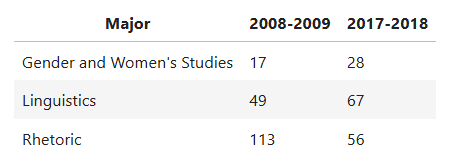

In [ ]:
import pandas as pd
data = {'Major': ['Gender', 'Linguistics', 'Rhetoric'], '2008-2009': [17, 49, 113], '2017-2018': [28, 67, 56]}
df = pd.DataFrame(data)
df = df.set_index('Major')
df

,2008-2009,2017-2018
Major,,
Gender,17,28
Linguistics,49,67
Rhetoric,113,56


###Question 1.
Suppose you want to find the biggest absolute difference between the number of degree recipients in the two years, among the three majors.

In the cell below, compute this value and call it biggest_change. Use a single expression (a single line of code) to compute the answer. Let Python perform all the arithmetic (like subtracting 49 from 67) rather than simplifying the expression yourself. The built-in abs function takes a numerical input and returns the absolute value. The built-in max function can take in 3 arguments and returns the maximum of the three numbers. (5 Points)

In [ ]:
biggest_change = max(abs(df['2008-2009'] - df['2017-2018']))
biggest_change

57

###Question 2.
Which of the three majors had the smallest absolute difference? Assign smallest_change_major to 1, 2, or 3 where each number corresponds to the following major:

1. Gender and Women's Studies
2. Linguistics
3. Rhetoric

Choose the number that corresponds to the major with the smallest absolute difference.

You should be able to answer by rough mental arithmetic, without having to calculate the exact value for each major. (4 Points)

In [ ]:
smallest_change_major = abs(df['2008-2009'] - df['2017-2018']).idxmin()
index_number = df.index.get_loc(smallest_change_major) + 1
index_number

1

Question 3. For each major, define the “relative change” to be the following:
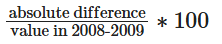

Fill in the code below such that gws_relative_change, linguistics_relative_change and rhetoric_relative_change are assigned to the relative changes for their respective majors. (5 Points)

In [ ]:
gws_relative_change = (abs(df['2008-2009'] - df['2017-2018']).Gender / 17) * 100
linguistics_relative_change = (abs(df['2008-2009'] - df['2017-2018']).Linguistics / 17) * 100
rhetoric_relative_change = (abs(df['2008-2009'] - df['2017-2018']).Rhetoric / 17) * 100
gws_relative_change, linguistics_relative_change, rhetoric_relative_change

(64.70588235294117, 105.88235294117648, 335.29411764705884)

###Question 3.
Assign biggest_rel_change_major to 1, 2, or 3 where each number corresponds to to the following:

1. Gender and Women's Studies
2. Linguistics
3. Rhetoric

Choose the number that corresponds to the major with the biggest relative change. (4 Points)

In [ ]:
list_major = [gws_relative_change, linguistics_relative_change, rhetoric_relative_change]
biggest_rel_change_major = list_major.index(max(list_major)) + 1
biggest_rel_change_major

3

##Nearsightedness Study

Myopia, or nearsightedness, results from a number of genetic and environmental factors. In 1999, Quinn et al studied the relation between myopia and ambient lighting at night (for example, from nightlights or room lights) during childhood.

###Question 1.
The data were gathered by the following procedure, reported in the study. "Between January and June 1998, parents of children aged 2-16 years [...] that were seen as outpatients in a university pediatric ophthalmology clinic completed a questionnaire on the child's light exposure both at present and before the age of 2 years." Was this study observational, or was it a controlled experiment? Explain. (5 Points)

The experimental was oberservational as the data gathered may be very subjective. Although the data may show correlations it is hard to say "How much light the child was exposed to" and determine the duration of exporsure as well as distance to the expeosure for those x amount of years (before age 2 to present).

###Question 2.
The study found that of the children who slept with a room light on before the age of 2, 55% were myopic. Of the children who slept with a night light on before the age of 2, 34% were myopic. Of the children who slept in the dark before the age of 2, 10% were myopic. The study concluded the following: "The prevalence of myopia [...] during childhood was strongly associated with ambient light exposure during sleep at night in the first two years after birth."

Do the data support this statement? Why or why not? You may interpret "strongly" in any reasonable qualitative way. (5 Points)

Yes, the data strongly supports the statement. This can be seen as when children were exposed to any form of light while sleeping (room/night light), a larger percentage of them were found to be myopic than those children who slept in the dark. The data strongly supports this correlation but, the percentage of children who were myopic althoug sleeping in the dark cannot be explained for. This can be explained by other confounding factors prevalent in the childs life such as exposure to screens of bright light throughout the date. Therefore, the statement is correct.

###Question 3.
On May 13, 1999, CNN reported the results of this study under the headline, "Night light may lead to nearsightedness." Does the conclusion of the study claim that night light causes nearsightedness? (5 Points)

The statement generally states that night lights cause nearsightedness whereas the experiment concludes that night light causes myopia only when children under the age of 2 are exposed to it. Also, the statement does not account for the time of day/ the duration one is exposed to night light for. Therefore, the claim/statement is wrong.

###Question 4.

The final paragraph of the CNN report said that "several eye specialists" had pointed out that the study should have accounted for heredity.

Myopia is passed down from parents to children. Myopic parents are more likely to have myopic children, and may also be more likely to leave lights on habitually (since the parents have poor vision). In what way does the knowledge of this possible genetic link affect how we interpret the data from the study? Explain. (5 Points)

Firstly, it is stated that the experiment was carried out simply to find out the correlation between myopia and exposure to light. The study was carried out after knowing about myopia being genetic to simply find out a correlation. Since, myopia is genetic, the data may be false. It may not be entirely false as we do not know if the children were children of myopic parents or not so, we have no idea if the test was fair. Because of this incomplete information about the test, we cannot interpret the data from the study as true but, we also don't know if the test had accounted for (accidently or purposefully) heredity.

##Studying the Survivors

The Reverend Henry Whitehead was skeptical of John Snow’s conclusion about the Broad Street pump. After the Broad Street cholera epidemic ended, Whitehead set about trying to prove Snow wrong. (The history of the event is detailed here.)

He realized that Snow had focused his analysis almost entirely on those who had died. Whitehead, therefore, investigated the drinking habits of people in the Broad Street area who had not died in the outbreak.

What is the main reason it was important to study this group? Assign either 1, 2, or 3 to the name survivor_answer below. (4 Points)

1. If Whitehead had found that many people had drunk water from the Broad Street pump and not caught cholera, that would have been evidence against Snow's hypothesis.

2. Survivors could provide additional information about what else could have caused the cholera, potentially unearthing another cause.

3. Through considering the survivors, Whitehead could have identified a cure for cholera.

In [ ]:
survivor_answer = 2 #In general
survivor_answer_Whitehead = 1

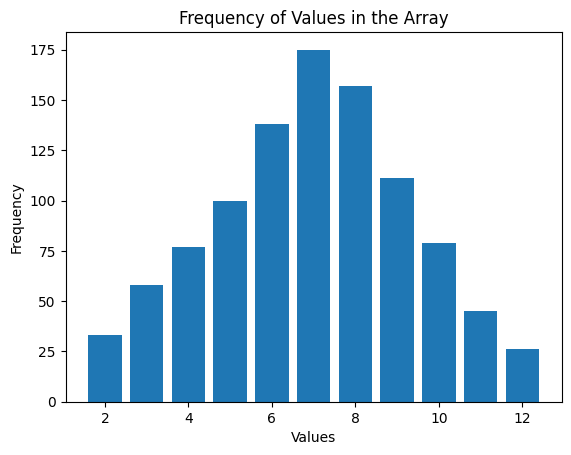

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
count = 1
arr = []
while (count != 1000):
  roll = random.randint(1,6) + random.randint(1,6)
  count = count + 1
  arr.append(roll)
unique_values, counts = np.unique(arr, return_counts=True)
plt.bar(unique_values, counts)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Frequency of Values in the Array")
plt.show()

#Project 2: The Monty Hall Problem

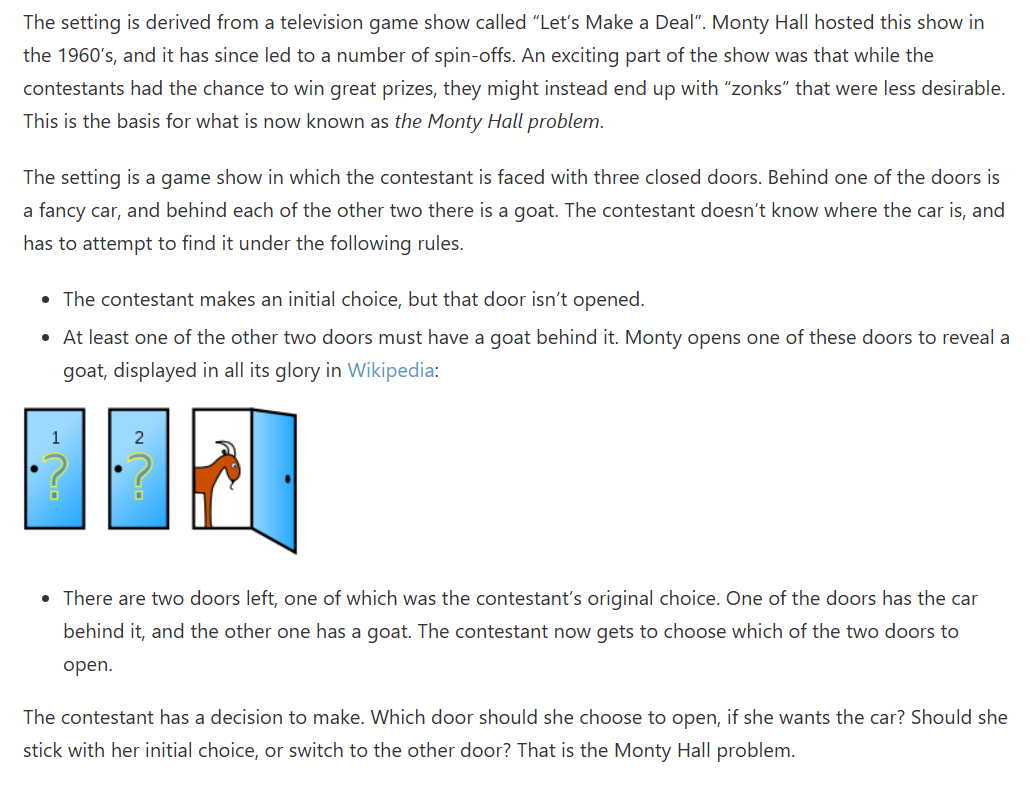

In [ ]:
#Monty Hall Problem
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def other_goat(x):
  if x == 'first_goat':
    return 'second_goat'
  elif x == 'second_goat':
    return 'first_goat'

def monty_hall_game(arr, goats):
  p_choice = np.random.choice(arr)
  if p_choice == 'car':
    revealed = np.random.choice(goats)
    return [p_choice, revealed, other_goat(revealed)]
  elif p_choice == 'first_goat':
    return [p_choice, 'second goat', 'car']
  elif p_choice == 'second_goat':
    return [p_choice, 'first_goat', 'car']

arr = np.array(["car", "first_goat", "second_goat"])
goats = np.array(['first_goat', 'second_goat'])

df = pd.DataFrame(columns=['Guess', 'revealed', 'remaining'])
for i in range(10000):
    game_result = monty_hall_game(arr, goats)
    df.loc[len(df)] = game_result

df.head()

,Guess,revealed,remaining
0,first_goat,second goat,car
1,first_goat,second goat,car
2,second_goat,first_goat,car
3,first_goat,second goat,car
4,car,second_goat,first_goat


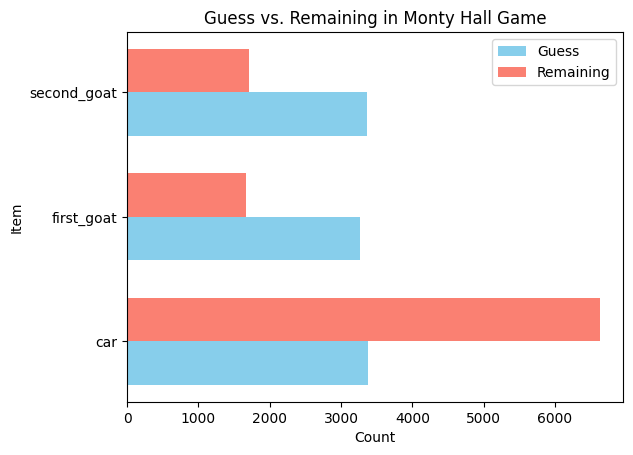

In [ ]:
items = ['car', 'first_goat', 'second_goat']

guess_counts = df.groupby('Guess')['Guess'].count()[items]
remaining_counts = df.groupby('remaining')['remaining'].count()[items]

# Create horizontal bar chart
fig, ax = plt.subplots()

# Bar positions for guess and remaining
bar_width = 0.35
x_pos_guess = [i for i in range(len(items))]
x_pos_remaining = [i + bar_width for i in range(len(items))]

ax.barh(x_pos_guess, guess_counts, bar_width, label='Guess', color='skyblue')
ax.barh(x_pos_remaining, remaining_counts, bar_width, label='Remaining', color='salmon')

# Set labels and title
ax.set_xlabel('Count')
ax.set_ylabel('Item')
ax.set_title('Guess vs. Remaining in Monty Hall Game')
ax.set_yticks([i + bar_width / 2 for i in range(len(items))])
ax.set_yticklabels(items)
ax.legend()

plt.show()

In [ ]:
prob_car_guess = guess_counts['car']/100
print(prob_car_guess)

prob_car_rem = remaining_counts['car']/100
print(prob_car_rem)

#This shows the probability of you guessing the car and the probability of you
#guessing the car if you switch your choice

33.76
66.24


#Test: Probability, Simulation, Estimation, and Assessing Models

A Nevada roulette wheel has 38 pockets and a small ball that rests on the wheel. When the wheel is spun, the ball comes to rest in one of the 38 pockets. That pocket is declared the winner.

The pockets are labeled 0, 00, 1, 2, 3, 4, ... , 36. Pockets 0 and 00 are green, and the other pockets are alternately red and black. The table wheel is a representation of a Nevada roulette wheel. Note that both columns consist of strings. Below is an example of a roulette wheel!

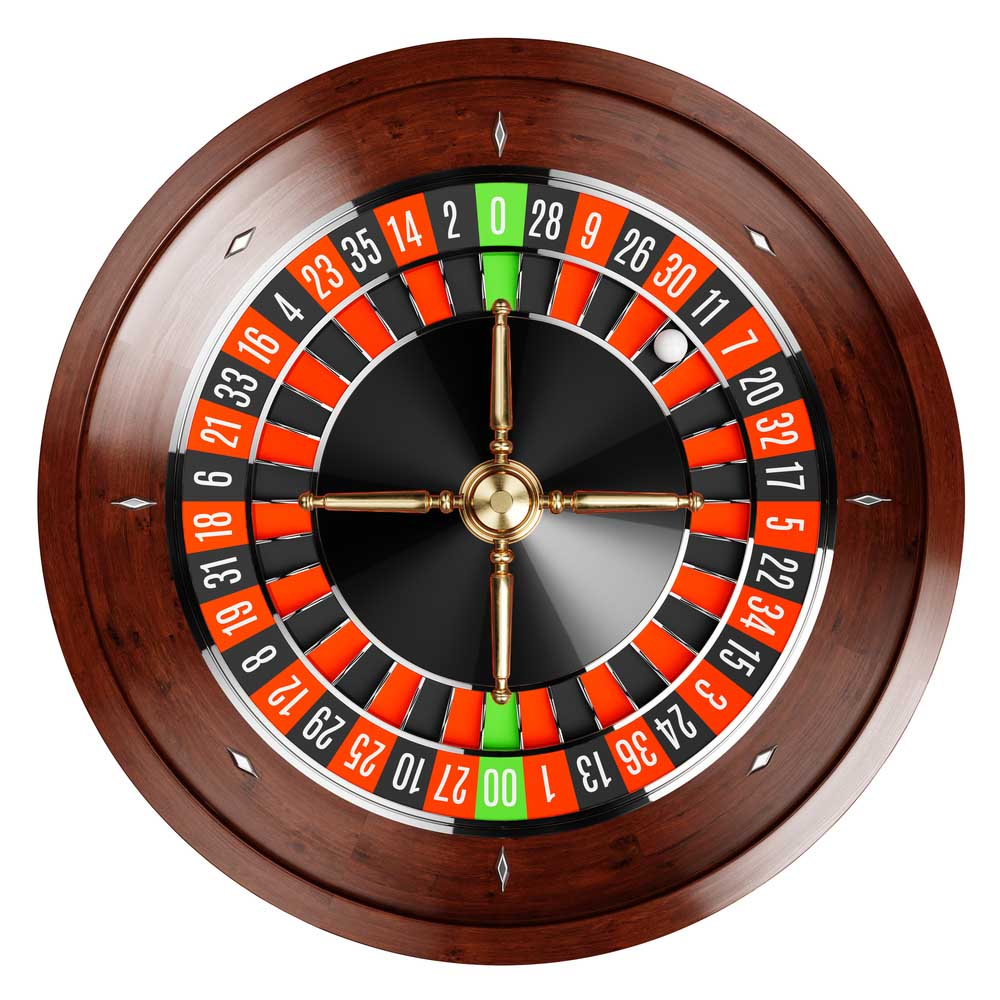

Load the wheel table.

In [ ]:
import pandas as pd
wheel = pd.read_excel('roulette_wheel.xlsx')
wheel = pd.DataFrame(wheel)
wheel = wheel.set_index('Pocket')
wheel

,Color
Pocket,
0,green
0,green
1,red
2,black
3,red
4,black
5,red
6,black
7,red


**Betting on Red¶**

If you bet on red, you are betting that the winning pocket will be red. This bet pays 1 to 1. That means if you place a one-dollar bet on red, then:

If the winning pocket is red, you gain 1 dollar. That is, you get your original dollar back, plus one more dollar.
if the winning pocket is not red, you lose your dollar. In other words, you gain -1 dollars.
Let's see if you can make money by betting on red at roulette.

##Question 1.
Define a function dollar_bet_on_red that takes the name of a color and returns your gain in dollars if that color had won and you had placed a one-dollar bet on red. Remember that the gain can be negative. Make sure your function returns an integer. (4 points)

Note: You can assume that the only colors that will be passed as arguments are red, black, and green. Your function doesn't have to check that.

In [ ]:
import numpy as np
def dollar_bet_on_red(color):
  # color_roll = np.random.choice(wheel['Color'])
  if color == "red":
    return 1
  else:
    return -1

In [ ]:
print(dollar_bet_on_red('green'))
print(dollar_bet_on_red('black'))
print(dollar_bet_on_red('red'))

-1
-1
1


##Question 2.
Add a column labeled Winnings: Red to the table wheel. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on red. Your code should use the function dollar_bet_on_red. (4 points)

In [ ]:
red_winnings = lambda color: dollar_bet_on_red(color)
wheel['Winnings: Red'] = wheel['Color'].apply(red_winnings)
wheel

,Color,Winnings: Red
Pocket,,
0,green,-1
0,green,-1
1,red,1
2,black,-1
3,red,1
4,black,-1
5,red,1
6,black,-1
7,red,1


**Simulating 10 Bets on Red**

Roulette wheels are set up so that each time they are spun, the winning pocket is equally likely to be any of the 38 pockets regardless of the results of all other spins. Let's see what would happen if we decided to bet one dollar on red each round.

##Question 3.
Create a table ten_bets by sampling the table wheel to simulate 10 spins of the roulette wheel. Your table should have the same three column labels as in wheel. Once you've created that table, set sum_bets to your net gain in all 10 bets, assuming that you bet one dollar on red each time. (4 points)

Hint: It may be helpful to print out ten_bets after you create it!

In [ ]:
ten_bets = wheel.sample(n=10, replace=True)
sum_bets = ten_bets['Winnings: Red'].sum()
sum_bets

-4

In [ ]:
ten_bets

,Color,Winnings: Red
Pocket,,
22,black,-1
5,red,1
36,red,1
0,green,-1
6,black,-1
13,black,-1
22,black,-1
1,red,1
4,black,-1


Run the cells above a few times to see how much money you would make if you made 10 one-dollar bets on red. Making a negative amount of money doesn't feel good, but it is a reality in gambling. Casinos are a business, and they make money when gamblers lose.

##Question 4.
Let's see what would happen if you made more bets. Define a function net_gain_red that takes the number of bets and returns the net gain in that number of one-dollar bets on red. (4 points)

Hint: You should use your wheel table within your function.

In [ ]:
def net_gain_red(n):
  n_bets = wheel.sample(n = n, replace=True)
  sum_bets = n_bets['Winnings: Red'].sum()
  return sum_bets

Run the cell below a few times to make sure that the results are similar to those you observed in the previous exercise.

In [ ]:
net_gain_red(100)

-4

##Question 5.
Complete the cell below to simulate the net gain in 200 one-dollar bets on red, repeating the process 10,000 times. After the cell is run, all_gains_red should be an array with 10,000 entries, each of which is the net gain in 200 one-dollar bets on red. (4 points)

Hint: Think about which computational tool might be helpful for simulating a process multiple times. Lab 5 might be a good resource to look at!

Note: This cell might take a few seconds to run.

In [ ]:
num_bets = 200
repetitions = 10000

all_gains_red = lambda: [net_gain_red(num_bets) for _ in range(repetitions)]
all_gains_red = pd.DataFrame(all_gains_red())

len(all_gains_red) # Do not change this line! Check that all_gains_red is length 10000.

10000

Visualize the results of your simulation.

array([[<Axes: title={'center': '0'}>]], dtype=object)

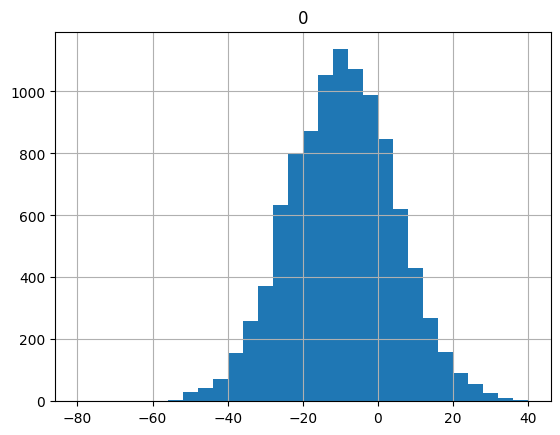

In [ ]:
gains = all_gains_red ##Net Gain on Red
gains.hist(bins = np.arange(-80, 41, 4))

##Question 6:
Using the histogram above, decide whether the following statement is true or false:

If you make 200 one-dollar bets on red, your chance of losing money is more than 50%.

Assign loss_more_than_50 to either True or False depending on your answer to the question. (4 points)

In [ ]:
loss_more_than_50 = True

**Betting on a Split¶**
If betting on red doesn't seem like a good idea, maybe a gambler might want to try a different bet. A bet on a split is a bet on two consecutive numbers such as 5 and 6. This bets pays 17 to 1. That means if you place a one-dollar bet on the split 5 and 6, then:

If the winning pocket is either 5 or 6, your gain is 17 dollars.
If any other pocket wins, you lose your dollar, so your gain is -1 dollars.

##Question 7.
Define a function dollar_bet_on_split that takes a pocket number and returns your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. (4 points)

Hint: Remember that the pockets are represented as strings.

In [ ]:
def dollar_bet_on_split(num):
    num = int(num)
    if num == 5 or num == 6:
      return 17
    else:
      return -1

Run the cell below to check that your function is doing what it should.

In [ ]:
print(dollar_bet_on_split('5'))
print(dollar_bet_on_split('6'))
print(dollar_bet_on_split('00'))
print(dollar_bet_on_split('23'))

17
17
-1
-1


##Question 8.
Add a column Winnings: Split to the wheel table. For each pocket, the column should contain your gain in dollars if that pocket won and you had bet one dollar on the 5-6 split. (4 points)

In [ ]:
split_winnings = lambda num: dollar_bet_on_split(num)
wheel['Winnings: Split'] = wheel.index.to_series().apply(split_winnings)
# wheel.show(5) # Do not change this line.
wheel

##Question 9.
Simulate the net gain in 200 one-dollar bets on the 5-6 split, repeating the process 10,000 times and saving your gains in the array all_gains_split. (4 points)

Hint: Your code in Questions 4 and 5 may be helpful here!

In [ ]:
def net_gain_split(n):
  n_bets = wheel.sample(n = n, replace=True)
  sum_bets = n_bets['Winnings: Split'].sum()
  return sum_bets

array([[<Axes: title={'center': '0'}>]], dtype=object)

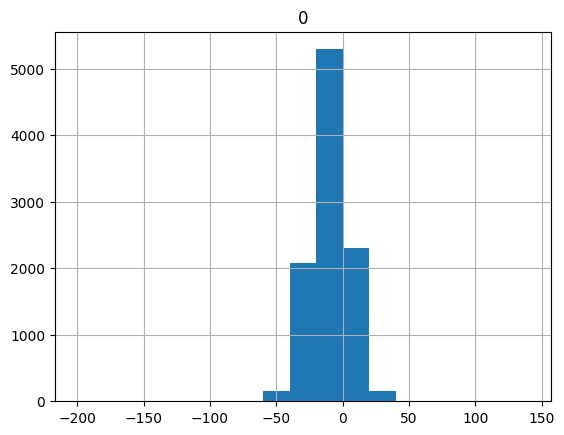

In [ ]:
num_bets = 200
repetitions = 10000
all_gains_split = lambda: [net_gain_red(num_bets) for _ in range(repetitions)]
all_gains_split = pd.DataFrame(all_gains_split())

# Do not change the two lines below
gains = all_gains_split # Net Gain on Split
gains.hist(bins = np.arange(-200, 150, 20))

##Question 10.
Look carefully at the visualization above, and assign histogram_statements to an array of the numbers of each statement below that can be correctly inferred from the overlaid histogram. (4 points)

1. If you bet one dollar 200 times on a split, your chance of losing money is more than 50%.
2. If you bet one dollar 200 times in roulette, your chance of making more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.
3. If you bet one dollar 200 times in roulette, your chance of losing more than 50 dollars is greater if you bet on a split each time than if you bet on red each time.

Hint: We've already seen one of these statements in a prior question.

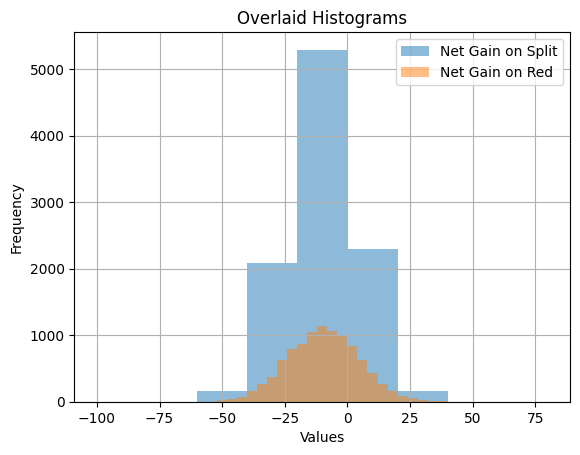

In [ ]:
# histogram_statements = [True, False, True]
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'all_gains_red' and 'all_gains_split' are your data

# Create the figure and axes
fig, ax = plt.subplots()  # Create a single set of axes

# Plot the histograms on the same axes
ax.hist(all_gains_split, bins=np.arange(-100, 100, 20), alpha=0.5, label='Net Gain on Split')
ax.hist(all_gains_red, bins=np.arange(-80, 41, 4), alpha=0.5, label='Net Gain on Red')

# Add labels and title
ax.set_xlabel('Values')
ax.set_ylabel('Frequency')
ax.set_title('Overlaid Histograms')
ax.grid(True, zorder=0)

# Add a legend
ax.legend()

# Show the plot
plt.show()
# To see the output, run the code.

If this exercise has put you off playing roulette, it has done its job. If you are still curious about other bets, here they all are, and here is the bad news. The house – that is, the casino – always has an edge over the gambler.

In [ ]:
histogram_statements = [True, True, True]

#Test: Finding Chances

On each spin of a roulette wheel, all 38 pockets are equally likely to be the winner regardless of the results of other spins. Among the 38 pockets, 18 are red, 18 black, and 2 green. In each part below, write an expression that evaluates to the chance of the event described.

In [ ]:
pockets = 38
color = 18
n_times = 3

##Question 1.
The winning pocket is black on all of the first three spins. (4 points)

In [ ]:
first_three_black = ((color/pockets)**n_times)*100
first_three_black

10.628371482723427

##Question 2.
The color green never wins in the first 10 spins. (4 points)

In [ ]:
color = 36
n_times = 10
no_green = ((color/pockets)**n_times)*100
no_green

58.235665322993924

##Question 3.
The color green wins at least once on the first 10 spins. (4 points)

In [ ]:
prob_not_green_in_n_spins = (36/38) ** n_times
at_least_one_green = (1 - prob_not_green_in_n_spins)*100
at_least_one_green

41.764334677006076

##Question 4.
Two of the three colors never win in the first 10 spins. (4 points)

Hint: Imagine the event with the colors red, yellow, and orange. What situation(s) lead to two of the three colors never winning in the first 10 spins?

In [ ]:
lone_winners = ...

**Comparing Chances¶**

In each of Questions 5-7, two events A and B are described. Choose from one of the following three options and set each answer variable to a single integer:

1. Event A is more likely than Event B
2. Event B is more likely than Event A
3. The two events have the same chance.

You should be able to make the choices without calculation. Good ways to approach this exercise include imagining carrying out the chance experiments yourself, one trial at a time, and by thinking about the law of averages.

##Question 5.
A child picks four times at random from a box that has four toy animals: a bear, an elephant, a giraffe, and a kangaroo. (4 points)

* Event A: all four different animals are picked (assuming the child picks without replacement)
* Event B: all four different animals are picked (assuming the child picks with replacement)

In [ ]:
toys_option = ...

##Question 6.

In a lottery, two numbers are drawn at random with replacement from the integers 1 through 1000. (4 points)

* Event A: The number 8 is picked on both draws
* Event B: The same number is picked on both draws

##Question 7.
A fair coin is tossed repeatedly. (4 points)

* Event A: There are 60 or more heads in 100 tosses
* Event B: There are 600 or more heads in 1000 tosses

Hint: Think about the law of averages!

In [ ]:
lottery_option = ...

# Emperical Distribution

In [ ]:
import random
import pandas as pd

# Simulate 10 throws of a dice and store in a list
outcomes = []
for _ in range(10):
  outcomes.append(random.randint(1, 6))

# Create a Pandas DataFrame from the list
df = pd.DataFrame({'Throw': outcomes})

# Display the table
df

,Throw
0,3
1,2
2,4
3,3
4,4
5,4
6,6
7,4
8,5
9,1


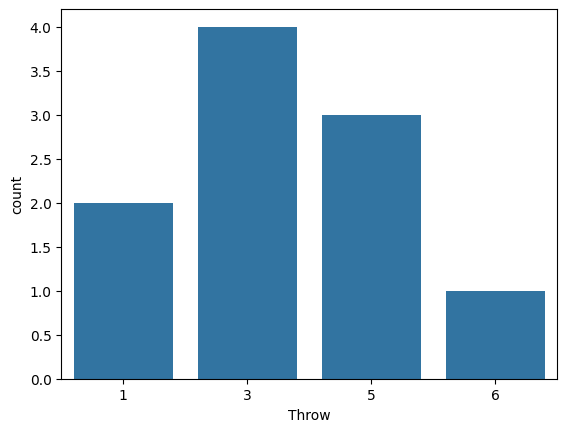

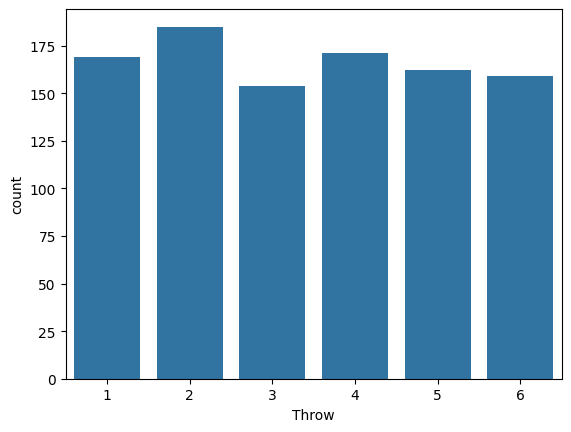

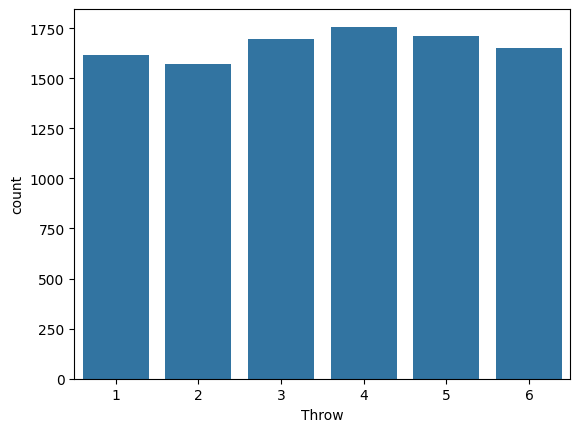

In [ ]:
import random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def sample(n):
  # Simulate 10 throws of a dice and store in a list
  outcomes = []
  for _ in range(n):
      outcomes.append(random.randint(1, 6))

  # Create a Pandas DataFrame from the list
  df = pd.DataFrame({'Throw': outcomes})

  # Create the vertical bar graph using seaborn
  sns.countplot(x='Throw', data=df)
  plt.show()

sample(10)
sample(1000)
sample(10000)

## United Summers - Flight delay

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('united.csv')

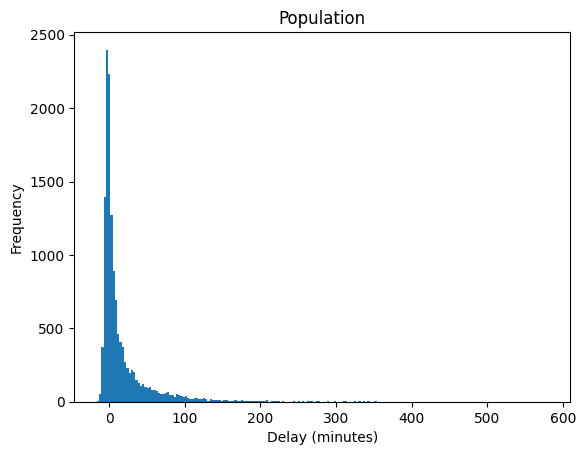

In [ ]:
plt.hist(df['Delay'], bins=200)
plt.xlabel('Delay (minutes)')
plt.ylabel('Frequency')
plt.title('Population')
plt.show()

In [ ]:
filtered_df = df[df['Delay'] <= 200]

In [ ]:
len(filtered_df)

13709

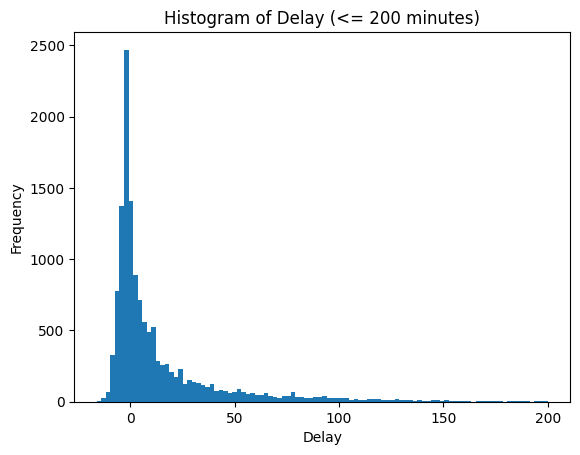

In [ ]:
plt.hist(filtered_df['Delay'], bins=100)  # You can still adjust the bin size
plt.xlabel('Delay')
plt.ylabel('Frequency')
plt.title('Histogram of Delay (<= 200 minutes)')
plt.show()

In [ ]:
def sample(n):
  data = filtered_df['Delay']
  sample = random.sample(list(data), n)  # Randomly sample n data points
  return sample

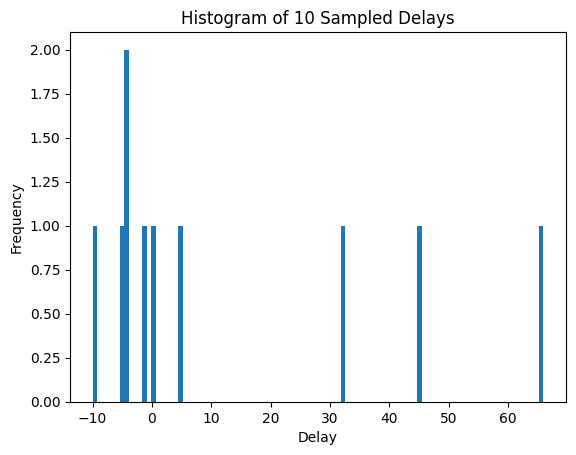

In [ ]:
n = 10
s = sample(n)
plt.hist(s, bins=100)
plt.xlabel('Delay')  # Assuming 'Delay' is the column name
plt.ylabel('Frequency')
plt.title(f'Histogram of {n} Sampled Delays')
plt.show()

In [ ]:
import numpy as np


In [ ]:
np.median(df['Delay'])

2.0

In [ ]:
np.median(filtered_df['Delay'])

2.0

In [ ]:
np.median(s)

-0.5

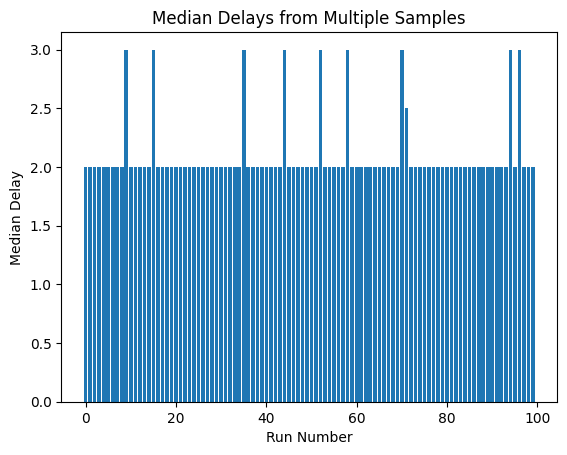

Average of medians: 2.095


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import random
import numpy as np

def sample_and_plot(data, n, bins=20):
  """Samples n data points from the population and plots a histogram."""
  sample = random.sample(list(data), n)
  plt.hist(sample, bins=bins)
  plt.xlabel('Delay')
  plt.ylabel('Frequency')
  plt.title(f'Histogram of {n} Sampled Delays')
  plt.show()

def sample_and_get_median(data, n):
  """Samples n data points and returns the median."""
  sample = random.sample(list(data), n)
  return np.median(sample)

# Run the sampling function multiple times and store the medians
num_runs = 100  # Adjust the number of runs as needed
sample_size = 6000  # Adjust the sample size as needed
medians = []

for _ in range(num_runs):
  median = sample_and_get_median(filtered_df['Delay'], sample_size)
  medians.append(median)

# Plot the vertical bar graph of medians
plt.bar(range(num_runs), medians)
plt.xlabel('Run Number')
plt.ylabel('Median Delay')
plt.title('Median Delays from Multiple Samples')
plt.show()

average_median = np.mean(medians)
print(f"Average of medians: {average_median}")

#Test : Three Ways Python Draws Random Samples

You have learned three ways to draw random samples using Python:


**Method 1: Using the random module**

The random module is part of the Python standard library. The most common function is random.sample(), which returns a list of unique elements chosen randomly from a sequence. This is useful if you don't want replacement of items. If you need items to be replaced, use random.choices(). If you need to randomly shuffle a list in place, use random.shuffle(). To get a random number from a range, use random.randrange() or, if you need a floating point number, random.random().

In [ ]:
import random

# Sample without replacement
my_list = [1, 2, 3, 4, 5]
random_sample = random.sample(my_list, 3)  # Choose 3 unique elements
print(random_sample)  # To see the output, run the code.

# Sample with replacement
random_sample_wr = random.choices(my_list, k=3)  # Choose 3 elements, with replacement
print(random_sample_wr)  # To see the output, run the code.

# Shuffle a list
random.shuffle(my_list)
print(my_list)  # To see the output, run the code.

# Get a random number
random_number = random.randrange(1, 10)  # Random number between 1 and 9
print(random_number)  # To see the output, run the code.
random_number = random.randrange(1, 10)  # Random number between 1 and 9
print(random_number)  # To see the output, run the code.
random_number = random.randrange(1, 10)  # Random number between 1 and 9
print(random_number)  # To see the output, run the code.

[2, 5, 4]
[2, 1, 5]
[5, 2, 3, 4, 1]
7
8
1


**Method 2: Using the numpy.random module**

The numpy.random module provides functions for generating random numbers and samples from various probability distributions. A common function for getting a random sample is numpy.random.choice(), which allows weighted samples as well.

In [ ]:
import numpy as np

# Sample without replacement
my_array = np.array([1, 2, 3, 4, 5])
random_sample = np.random.choice(my_array, size=3, replace=False)
print(random_sample)  # To see the output, run the code.

# Sample with replacement
random_sample_wr = np.random.choice(my_array, size=3, replace=True)
print(random_sample_wr)  # To see the output, run the code.

# Sample with weights
weights = [0.1, 0.2, 0.3, 0.2, 0.2]  # Weights for each element
random_sample_weighted = np.random.choice(my_array, size=3, replace=True, p=weights)
print(random_sample_weighted)  # To see the output, run the code.

[1 2 5]
[1 2 1]
[1 3 4]


**Method 3: Using the pandas.DataFrame.sample method**

If you are working with a pandas DataFrame, you can directly use the sample() method to draw a random sample of rows or columns.

In [ ]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame({'col1': [1, 2, 3, 4, 5], 'col2': ['A', 'B', 'C', 'D', 'E']})

# Sample rows
random_sample_rows = df['col2'].sample(n=3, replace=True)  # Sample 3 rows
print(random_sample_rows)  # To see the output, run the code.

# Sample columns
random_sample_cols = df.sample(axis='columns', n=1, replace=False)  # Sample 1 column
print(random_sample_cols)  # To see the output, run the code.

1    B
4    E
2    C
Name: col2, dtype: object
  col2
0    A
1    B
2    C
3    D
4    E


Look through this code and run this cell for questions 1 and 2

In [ ]:
import numpy as np
import pandas as pd

top_df = pd.read_csv('top_movies_2017.csv')

top_df = top_df[['Title', 'Studio']]

studios_with_counts_df = top_df.groupby('Studio').size().reset_index(name='count').sort_values('count', ascending=False)

In [ ]:
studios_with_counts_df.head()

,Studio,count
1,Buena Vista,35
22,Warner Brothers,29
13,Paramount,25
5,Fox,24
21,Universal,23


In [ ]:
studios_of_all_movies_np = top_df['Studio'].to_numpy()
distinct_studios_np = studios_with_counts_df['Studio'].to_numpy()
studio_counts_only_np = studios_with_counts_df['count'].to_numpy()

In [ ]:
studio_counts_only_np

array([35, 29, 25, 24, 23, 11,  9,  7,  6,  5,  4,  4,  3,  3,  3,  2,  1,
        1,  1,  1,  1,  1,  1])

In [ ]:
np.sum(studio_counts_only_np)

200

In [ ]:
studio_proportions_only_np = studio_counts_only_np / np.sum(studio_counts_only_np)

In [ ]:
studio_proportions_only_np

array([0.175, 0.145, 0.125, 0.12 , 0.115, 0.055, 0.045, 0.035, 0.03 ,
       0.025, 0.02 , 0.02 , 0.015, 0.015, 0.015, 0.01 , 0.005, 0.005,
       0.005, 0.005, 0.005, 0.005, 0.005])

In Questions 1 and 2, we will present a scenario. Determine which three of the following six options are true in regards to what the question is asking, and list them in the following answer cell. If your answer includes any of (i)-(iii), state what you would fill in the blank to make it true: top, studios_with_counts, studios_of_all_movies, distinct_studios, studio_counts_only or studio_proportions_only.

(i) This can be done using sample and the table _________.

(ii) This can be done using np.random.choice and the array ________.

(iii) This can be done using sample_proportions and the array _______.

(iv) This cannot be done using sample and the data given.

(v) This cannot be done using np.random.choice and the data given.

(vi) This cannot be done using sample_proportions and the data given.

##Question 1.
Simulate a sample of 10 movies drawn at random with replacement from the 200 movies. Outputs True if Paramount appears more often than Warner Brothers among studios that released the sampled movies, and False otherwise. (4 points)

Example Answer: (i) studios_of_all_movies, (iii) top, (v)

Note: Do not explain your answer for any of the options you've chosen; please follow the structure of the example answer provided.


In [ ]:
ten_sample_1 = np.random.choice(studios_of_all_movies_np, size=10, replace=True)
print(ten_sample_1)  # To see the output, run the code.

['Columbia' 'Paramount' 'Universal' 'Warner Brothers' 'Buena Vista'
 'Buena Vista' 'Fox' 'Buena Vista' 'Buena Vista' 'Selz.']


In [ ]:
sample_10 = top_df.sample(n=10, replace=True)  # Sample 3 rows
sample_10 # To see the output, run the code.

,Title,Studio
73,West Side Story,MGM
14,Avatar,Fox
37,Spider-Man,Sony
125,Wonder Woman,Warner Brothers
130,"The Chronicles of Narnia: The Lion, the Witch ...",Buena Vista
188,Iron Man 2,Paramount
57,Cinderella (1950),Disney
66,The Dark Knight Rises,Warner Brothers
108,Spider-Man 3,Sony
113,Top Gun,Paramount


In [ ]:
sample_10_sorted = sample_10.groupby('Studio').size().reset_index(name='count').sort_values('count', ascending=False)
sample_10_sorted

,Studio,count
4,Paramount,2
5,Sony,2
6,Warner Brothers,2
0,Buena Vista,1
1,Disney,1
2,Fox,1
3,MGM,1


(i) This can be done using sample and the table _____.

(ii) This can be done using np.random.choice and the array ____.

(iii) This can be done using sample_proportions and the array ___.

(iv) This cannot be done using sample and the data given.

(v) This cannot be done using np.random.choice and the data given.

(vi) This cannot be done using sample_proportions and the data given.

##Question 2.
Simulate a sample of 10 movies drawn at random with replacement from the 200 movies. Outputs True if the first sampled movie was released by the same studio as the last sampled movie. (4 points)

Example Answer: (i) studios_of_all_movies, (iii) top, (v)

Note: Do not explain your answer for any of the options you've chosen; please follow the structure of the example answer provided.

In [ ]:
sample_10_2 = top_df.sample(n=10, replace=True)  # Sample 3 rows
sample_10_2 # To see the output, run the code.

,Title,Studio
135,The Caine Mutiny,Columbia
122,Crocodile Dundee,Paramount
112,How the Grinch Stole Christmas,Universal
43,Goldfinger,United Artists
26,Mary Poppins,Disney
79,Rocky,United Artists
131,Harry Potter and the Goblet of Fire,Warner Brothers
142,Dances with Wolves,Orion
19,The Sting,Universal
112,How the Grinch Stole Christmas,Universal


(i) This can be done using sample and the table _____.

(ii) This can be done using np.random.choice and the array ____.

(iii) This can be done using sample_proportions and the array ___.

(iv) This cannot be done using sample and the data given.

(v) This cannot be done using np.random.choice and the data given.

(vi) This cannot be done using sample_proportions and the data given.

# Test: Assessing Jade's Models

Before you begin, Section 10.4 of the textbook is a useful reference for this part.

Games with Jade
Our friend Jade comes over and asks us to play a game with her. The game works like this:


> We will draw randomly with replacement from a simplified 13 card deck with 4 face cards (A, J, Q, K), and 9 numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10). If we draw cards with replacement 13 times, and if the number of face cards is greater than or equal to 4, we lose. Otherwise, Jade loses.


We play the game once and we lose, observing 8 total face cards. We are angry and accuse Jade of cheating! Jade is adamant, however, that the deck is fair.

Jade's model claims that there is an equal chance of getting any of the cards (A, 2, 3, 4, 5, 6, 7, 8, 9, 10, J, Q, K), but we do not believe her. We believe that the deck is clearly rigged, with face cards (A, J, Q, K) being more likely than the numbered cards (2, 3, 4, 5, 6, 7, 8, 9, 10).

##Question 1.

Assign deck_model_probabilities to a two-item array containing the chance of drawing a face card as the first element, and the chance of drawing a numbered card as the second element under Jade's model. Since we're working with probabilities, make sure your values are between 0 and 1. (4 Points)

In [ ]:
deck_model_probabilities = [(4/13), 9/13]
deck_model_probabilities

[0.3076923076923077, 0.6923076923076923]

##Question 2.

We believe Jade's model is incorrect. In particular, we believe there to be a larger chance of getting a face card. Which of the following statistics can we use during our simulation to test between the model and our alternative? Assign statistic_choice to the correct answer. (5 Points)

1. The distance (absolute value) between the actual number of face cards in 13 draws and 4, the expected number of face cards in 13 draws
2. The expected number of face cards in 13 draws, 4
3. The number of face cards we get in 13 draws

In [ ]:
statistic_choice = 3
statistic_choice

3

##Question 3.
Define the function deck_simulation_and_statistic, which, given a sample size and an array of model proportions (like the one you created in Question 1), returns the number of face cards in one simulation of drawing cards under the model specified in model_proportions. (5 Points)

Hint: Think about how you can use the function sample_proportions.

In [ ]:
from datascience import *
import numpy as np
def deck_simulation_and_statistic(sample_size, model_proportions):
  num_face_cards = int(sample_size * model_proportions[0])
  num_numbered_cards = sample_size - num_face_cards
  card_sample = np.concatenate([
      np.repeat('F', num_face_cards),
      np.repeat('N', num_numbered_cards)
  ])
  arr_drawn = np.random.choice(card_sample, sample_size, replace = True)
  return np.count_nonzero(arr_drawn == 'F')

face_cards = deck_simulation_and_statistic(13, deck_model_probabilities)
face_cards

1

##Question 4.
Use your function from above to simulate the drawing of 13 cards 5000 times under the proportions that you specified in Question 1. Keep track of all of your statistics in deck_statistics. (5 Points)

In [ ]:
import pandas as pd
repetitions = 5000
deck_stats_list = []  # Store results in a list
for i in range(repetitions):
  result = deck_simulation_and_statistic(13, deck_model_probabilities)
  deck_stats_list.append(result)
deck_statistics = np.array(deck_stats_list, dtype=[('face_cards', int)])  # Convert to NumPy array
deck_statistics = pd.DataFrame(deck_statistics)
deck_statistics

,face_cards
0,3
1,3
2,2
3,2
4,8
...,...
4995,1
4996,6
4997,7
4998,4


Let’s take a look at the distribution of simulated statistics.

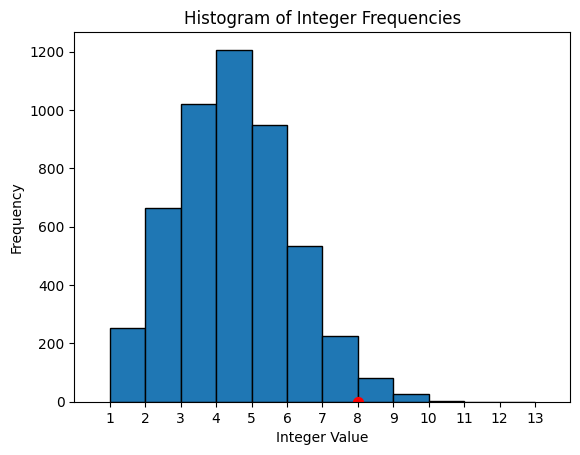

In [ ]:
import matplotlib.pyplot as plt

# Assuming 'face_cards' is the column with the integer values
plt.hist(deck_statistics['face_cards'], bins=range(1, 14), edgecolor='black')
plt.xlabel('Integer Value')
plt.ylabel('Frequency')
plt.title('Histogram of Integer Frequencies')
plt.xticks(range(1, 14)) # Set x-axis ticks to show all integer values
plt.xlim(0, 14)
%matplotlib inline
plt.scatter(8,0, s = 50, c = 'red')
plt.show()

##Question 5.
Given your observed value, do you believe that Jade's model is reasonable, or is our alternative (that our deck is rigged) more likely? Explain your answer using the histogram produced above. (5 Points)

In [ ]:
#Jade's model is reasonable as there are a few possibilities where 8 face
#cards are drawn. However, we have no way to prove that it is not rigged as
#8 is on the higher end of the plot making it slightly less probable.

#Testing Hypotheses

## Lecture

In [ ]:
sample_size = 100
eligible_population = [0.26, 0.74]

In [ ]:
from datascience import *
import numpy as np

# def sample_proportions(sample_size, eligible_population):
#   """
#   Returns an array of sample proportions.

#   Args:
#     sample_size: The size of each sample to take from the eligible population.
#     eligible_population: A list of values representing the eligible population.

#   Returns:
#     An array of sample proportions.
#   """
#   # Calculate the number of samples to take
#   num_samples = len(eligible_population) // sample_size

#   # Initialize an empty list to store the sample proportions
#   sample_proportions = []

#   # Take multiple samples and calculate the proportion of successes in each sample
#   for i in range(num_samples):
#     # Take a random sample from the eligible population
#     sample = np.random.choice(eligible_population, size=sample_size, replace=False)

#     # Calculate the proportion of successes in the sample
#     proportion = np.sum(sample) / sample_size

#     # Append the proportion to the list of sample proportions
#     sample_proportions.append(proportion)

#   # Convert the list of sample proportions to an array
#   sample_proportions = np.array(sample_proportions)

#   return sample_proportions

In [ ]:
sample_proportions(sample_size, eligible_population).item(0)

0.32

In [ ]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population).item(0)

In [ ]:
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())

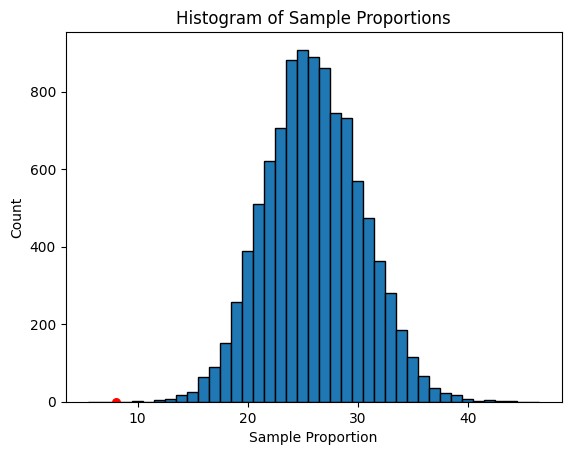

In [ ]:
import matplotlib.pyplot as plt

# Create the histogram
plt.hist(counts, bins=np.arange(5.5, 46.6, 1), edgecolor='black')  # Adjust bins as needed

# Set labels and title
plt.xlabel('Sample Proportion')
plt.ylabel('Count')
plt.title('Histogram of Sample Proportions')

plt.scatter(8, 0, color='red', s=30);

# Display the histogram
plt.show()

In [ ]:
from datascience import *
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)

jury

Ethnicity,Eligible,Panels
Asian/PI,0.15,0.26
Black/AA,0.18,0.08
Caucasian,0.54,0.54
Hispanic,0.12,0.08
Other,0.01,0.04


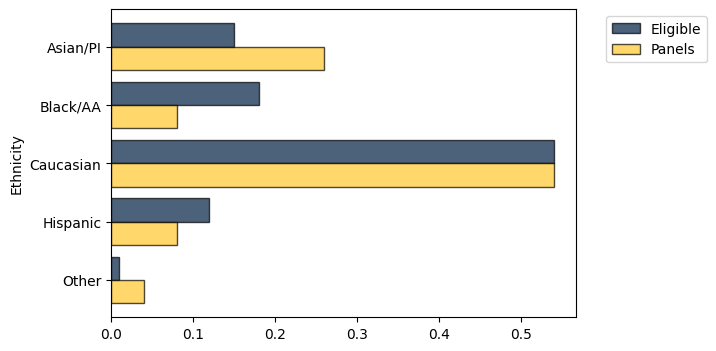

In [ ]:
%matplotlib inline
jury.barh('Ethnicity')

In [ ]:
eligible_population = jury.column('Eligible')
sample_distribution = sample_proportions(1453, eligible_population)
panels_and_sample = jury.with_column('Random Sample', sample_distribution)
panels_and_sample

Ethnicity,Eligible,Panels,Random Sample
Asian/PI,0.15,0.26,0.144529
Black/AA,0.18,0.08,0.176875
Caucasian,0.54,0.54,0.56022
Hispanic,0.12,0.08,0.110117
Other,0.01,0.04,0.00825877


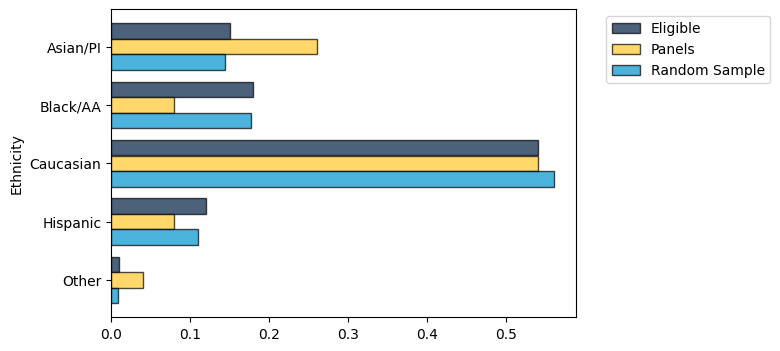

In [ ]:
panels_and_sample.barh('Ethnicity')

In [ ]:
# Augment the table with a column of differences between proportions

jury_with_diffs = jury.with_column(
    'Difference', jury.column('Panels') - jury.column('Eligible')
)
jury_with_diffs

Ethnicity,Eligible,Panels,Difference
Asian/PI,0.15,0.26,0.11
Black/AA,0.18,0.08,-0.1
Caucasian,0.54,0.54,0
Hispanic,0.12,0.08,-0.04
Other,0.01,0.04,0.03


In [ ]:
import numpy as np
jury_with_diffs = jury_with_diffs.with_column(
    'Absolute Difference', np.abs(jury_with_diffs.column('Difference'))
)

jury_with_diffs

Ethnicity,Eligible,Panels,Difference,Absolute Difference
Asian/PI,0.15,0.26,0.11,0.11
Black/AA,0.18,0.08,-0.1,0.1
Caucasian,0.54,0.54,0,0
Hispanic,0.12,0.08,-0.04,0.04
Other,0.01,0.04,0.03,0.03


In [ ]:
jury_with_diffs.column('Absolute Difference').sum() / 2

0.14000000000000001

In [ ]:
def total_variation_distance(distribution_1, distribution_2):
    return sum(np.abs(distribution_1 - distribution_2)) / 2

total_variation_distance(jury.column('Panels'), jury.column('Eligible'))

0.14000000000000001

In [ ]:
sample_distribution = sample_proportions(1453, eligible_population)
total_variation_distance(sample_distribution, eligible_population)

0.026951135581555406

In [ ]:
# Simulate one simulated value of
# the total variation distance between
# the distribution of a sample selected at random
# and the distribution of the eligible population

def one_simulated_tvd():
    sample_distribution = sample_proportions(1453, eligible_population)
    return total_variation_distance(sample_distribution, eligible_population)

In [ ]:
tvds = make_array()
repetitions = 5000
for i in np.arange(repetitions):
    tvds = np.append(tvds, one_simulated_tvd())

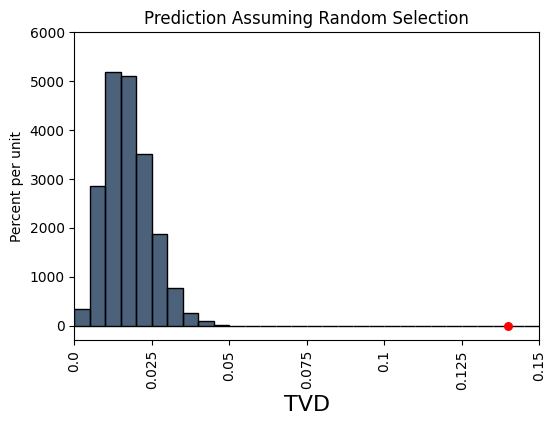

In [ ]:
import matplotlib.pyplot as plt
Table().with_column('TVD', tvds).hist(bins=np.arange(0, 0.2, 0.005))

# Plotting parameters; you can ignore this code
plt.title('Prediction Assuming Random Selection')
plt.xlim(0, 0.15)
plt.ylim(-3, 60)
plt.scatter(0.14, 0, color='red', s=30);

#Test: Vaccinations Across The Nation

A vaccination clinic has two types of vaccines against a disease. Each person who comes in to be vaccinated gets either Vaccine 1 or Vaccine 2. One week, everyone who came in on Monday, Wednesday, and Friday was given Vaccine 1. Everyone who came in on Tuesday and Thursday was given Vaccine 2. The clinic is closed on weekends.

Doctor DeNero at the clinic said, "Oh wow, it's just like tossing a coin that lands heads with chance 3/5. Heads you get Vaccine 1 and Tails you get Vaccine 2."

But Doctor Sahai said, "No, it's not. We're not doing anything like tossing a coin."

That week, the clinic gave Vaccine 1 to 211 people and Vaccine 2 to 107 people. Conduct a test of hypotheses to see which doctor's position is better supported by the data.

##Question 1.
Given the information above, what was the sample size for the data, and what was the percentage of people who got Vaccine 1? (4 points)

Note: Your percent should be a number between 0 and 100.

In [ ]:
sample_size = 318
percent_V1 = 66.4

print(f"Sample Size: {sample_size}")
print(f"Vaccine 1 Percent: {percent_V1}")

Sample Size: 318
Vaccine 1 Percent: 66.4


##Question 2.

State the null hypothesis. It should reflect the position of either Dr. DeNero or Dr. Sahai. (4 points)

Note: Check out 11.3 for a refresher on hypotheses.

In [ ]:
#Chance of getting vaccine 1 is 3/5 whereas the chance of getting vaccine 2 is 2/5

## Question 3.

State the alternative hypothesis. It should reflect the position of the doctor you did not choose to represent in Question 1.2. (4 points)

Note: Check out 11.3 for a refresher on hypotheses.

In [ ]:
#This is not a coin toss model and there is no probability involved

## Question 4.

One of the test statistics below is appropriate for testing these hypotheses. Assign the variable valid_test_stat to the number corresponding to the correct test statistic. (4 points)

1. percent of heads - 60
2. percent of heads - 50
3. |percent of heads - 60|
4. |percent of heads - 50|

In [ ]:
valid_test_stat = (percent_V1 - 60)
valid_test_stat

6.400000000000006

## Question 5.

Using your answer from Questions 1.1 and 1.4, find the observed value of the test statistic and assign it to the variable observed_statistic. (4 points)

In [ ]:
observed_statistic = 6.4
observed_statistic

6.4

## Question 6.

In order to perform this hypothesis test, you must simulate the test statistic. From the four options below, pick the assumption that is needed for this simulation. Assign assumption_needed to an integer corresponding to the assumption. (4 points)

1. The statistic must be simulated under the null hypothesis.
2. The statistic must be simulated under the alternative hypothesis.
3. The statistic must be simulated under both hypotheses.
4. No assumptions are needed. We can just simulate the statistic.

In [ ]:
assumption_needed = 1
assumption_needed

## Question 7.

Simulate 20,000 values of the test statistic under the assumption you picked in Question 1.6. (4 points)

As usual, start by defining a function that simulates one value of the statistic. Your function should use sample_proportions. (You may find a variable defined in Question 1.1 useful here!) Then, write a for loop to simulate multiple values and collect them in the array simulated_statistics.

Use as many lines of code as you need. We have included the code that visualizes the distribution of the simulated values. The red dot represents the observed statistic you found in Question 1.5.

In [ ]:
from datascience import *
def one_simulated_statistic(sample_size, valid_test_stat):
  eligible_population = [0.6, 0.4]
  per_V1 = sample_proportions(sample_size, eligible_population).item(0)
  # return valid_test_stat - per_V1
  return per_V1

num_simulations = 20000

simulated_statistics = []
for i in range (0, num_simulations):
    simulated_statistics.append(one_simulated_statistic(sample_size, valid_test_stat))

# Run the this cell a few times to see how the simulated statistic changes
one_simulated_statistic(318, valid_test_stat)

0.6540880503144654

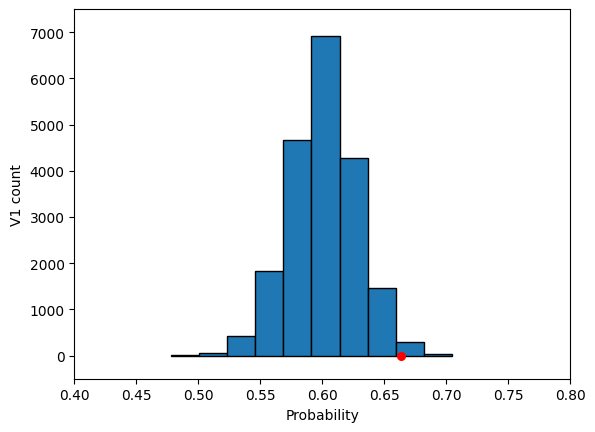

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'simulated_statistics' is your array of 20,000 integers
plt.hist(simulated_statistics)

# Set labels for the axes
plt.xlabel("Probability")
plt.ylabel("V1 count")

plt.xlim(0.4, 0.8)
plt.ylim(-500, 7500)
plt.scatter(211/318, 0, color='red', s=30);

%matplotlib inline
# Display the histogram
plt.show()

## Question 8.

Using simulated_statistics, observed_statistic, and num_simulations, find the empirical p-value based on the simulation. (4 points)

In [ ]:
p_value = ...
p_value

## Question 9.

Assign correct_doctor to the number corresponding to the correct statement below. Use the 5% cutoff for the p-value. (4 points)

1. The data support Dr. DeNero's position more than they support Dr. Sahai's.
2. The data support Dr. Sahai's position more than they support Dr. DeNero's.
As a reminder, here are the two claims made by Dr. DeNero and Dr. Sahai:

> Doctor DeNero: "Oh wow, it's just like tossing a coin that lands heads with chance 3/5. Heads you get Vaccine 1 and Tails you get Vaccine 2."

> Doctor Sahai: "No, it's not. We're not doing anything like tossing a coin."

In [ ]:
correct_doctor = ...
correct_doctor

Ellipsis

#Test: Using TVD as a Test Statistic


Total variation distance (TVD) is a special type of test statistic that we use when we want to compare two distributions of categorical data. It is often used when we observe that a set of observed proportions/probabilities is different than what we expect under the null model.

Consider a six-sided die that we roll 6,000 times. If the die is fair, we would expect that each face comes up 1/6 of the time. By random chance, a fair die won't always result in equal proportions (that is, we won't get exactly 1,000 of each face). However, if we suspect that the die might be unfair based on the data, we can conduct a hypothesis test using TVD to compare the expected [1/6, 1/6, 1/6, 1/6, 1/6, 1/6] distribution to what is actually observed.

In this part of the homework, we'll look at how we can use TVD to determine the effect that different factors have on happiness.

We will be working with data from the Gallup World Poll that is presented in the World Happiness Report, a survey of the state of global happiness. The survey ranked 155 countries by overall happiness and estimated the influence that economic production, social support, life expectancy, freedom, absence of corruption, and generosity had on population happiness. The study has been repeated for several years, but we'll be looking at data from the 2016 survey.

Run the cell below to load in the happiness_scores table.

In [ ]:
import pandas as pd
happiness_scores = pd.read_csv('happiness_scores.csv')
happiness_scores.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492


Participants in the study were asked to evaluate their life satisfaction from a scale of 0 (worst possible life) to 10 (best possible life). The responses for each country were averaged to create the Happiness Score.

The columns Economy (GDP per Capita), Family, Health (Life Expectancy), Freedom, Trust (Government Corruption), and Generosity estimate the extent to which each factor influences happiness, both for better or for worse. The happiness score is the sum of these factors; the larger a factor is, the more it contributes to overall happiness. [In other words, if you add up all the factors (in addition to a "Difference from Dystopia" value we excluded in the dataset), you get the happiness score.]

Let's look at the different factors that affect happiness in the United States. Run the cell below to view the row in us_happiness that contains data for the United States.

In [ ]:
us_row = happiness_scores[happiness_scores['Country'] == 'United States']
us_row

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
12,United States,North America,13,7.104,7.02,7.188,1.50796,1.04782,0.779,0.48163,0.14868,0.41077


To compare the different factors, we'll look at the proportion of the happiness score that is attributed to each variable. You can find these proportions in the table us_happiness_factors after running the cell below.

Note: The factors shown in us_happiness don't add up exactly to the happiness score, so we adjusted the proportions to only account for the data we have access to. The proportions were found by dividing each Happiness Factor value by the sum of all Happiness Factor values in us_happiness.

In [ ]:
usa = pd.read_csv('us_happiness_factors.csv')
usa

,Happiness Factor,Proportion of Happiness Score
0,Economy (GDP per Capita),0.344609
1,Family,0.239455
2,Health (Life Expectancy),0.178022
3,Freedom,0.110065
4,Trust (Government Corruption),0.033977
5,Generosity,0.093872


##Question 1.

Suppose we want to test whether or not each factor contributes the same amount to the overall Happiness Score. Define the null hypothesis, alternative hypothesis, and test statistic in the cell below. Feel free to check your work with another student or course staff. (4 points)

Note: Please format your answer as follows:

* Null Hypothesis: ...
* Alternative Hypothesis: ...
* Test Statistic: ...

In [ ]:
null_hypothesis = 'The factors do contribute the same amount to the overall Happiness Score.'
alternative_hypothesis = 'The factors do not contribute the same amount to the overall Happiness Score.'
test_statistic = 'TVD of the Proportion of Happiness Score'

## Question 2.

Write a function calculate_tvd that takes in the observed distribution (obs_dist) and expected distribution under the null hypothesis (null_dist) and calculates the total variation distance. Use this function to set observed_tvd to be equal to the observed test statistic. (4 points)

In [ ]:
import numpy as np
null_distribution = np.ones(6) * (1/6)

def calculate_tvd(obs_dist, null_dist):
    tvd = (np.sum(np.abs(obs_dist - null_dist)))/2
    return tvd

observed_tvd = calculate_tvd(usa['Proportion of Happiness Score'], null_distribution)
observed_tvd

0.26208562431156396

## Question 3.

Create an array called simulated_tvds that contains 10,000 simulated values under the null hypothesis. Assume that the original sample consisted of 1,000 individuals. (4 points)

Hint: The sample_proportions function may be helpful to you. Refer to the Python Reference Sheet to read up on it!

In [ ]:
from datascience import *

simulated_tvds = []
for i in range (10000):
  x = calculate_tvd(sample_proportions(1000, null_distribution), null_distribution)
  simulated_tvds.append(x)
simulated_tvds

Run the cell below to plot a histogram of your simulated test statistics, as well as a red dot representing the observed value of the test statistic.

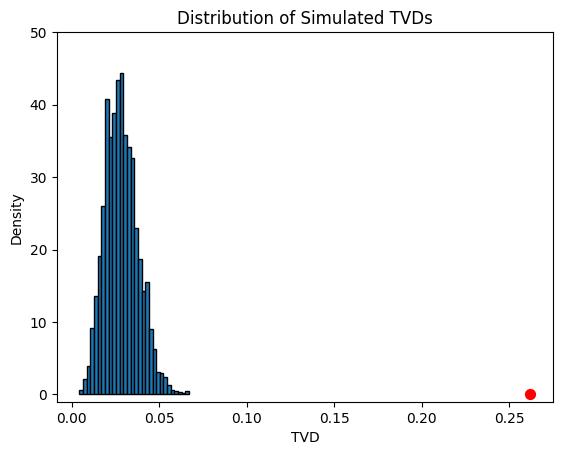

In [ ]:
import matplotlib.pyplot as plt

plt.hist(simulated_tvds, bins=30, density=True)
plt.scatter(observed_tvd, 0, color='red', s=50, zorder=2)
plt.xlabel('TVD')
plt.ylabel('Density')
plt.title('Distribution of Simulated TVDs')
plt.ylim(-1, 50)
%matplotlib inline
plt.show()

## Question 4.

Use your simulated statistics to calculate the p-value of your test. Make sure that this number is consistent with what you observed in the histogram above. (4 points)

In [ ]:
p_value_tvd = 0
p_value_tvd

## Question 5.

What can you conclude about how each factor contributes to the overall happiness score in the US? Explain your answer using the results of your hypothesis test. Assume a p-value cutoff of 5%. (4 points)

In [ ]:
'''The factors that contribute to the overall happiness score in the US
do not contribute evenly. This proves the alternate hypotheis.
'''

# Test: Who is Older?

Data scientists have drawn a simple random sample of size 500 from a large population of adults. Each member of the population happened to identify as either "male" or "female". Data was collected on several attributes of the sampled people, including age. The table sampled_ages contains one row for each person in the sample, with columns containing the individual's gender identity.

In [ ]:
import pandas as pd
import numpy as np
sampled_ages = pd.read_csv('age.csv')
sampled_ages

,Gender,Age
0,male,23
1,male,29
2,male,29
3,female,49
4,female,33
...,...,...
495,female,35
496,male,30
497,female,48
498,male,34


## Question 1.

How many females were there in our sample? Please use the provided skeleton code. (4 points)

Hint: Keep in mind that .group sorts categories in alphabetical order!

In [ ]:
num_females = sampled_ages[sampled_ages['Gender'] == 'female'].shape[0]
num_females

260

## Question 2.

Complete the cell below so that avg_male_vs_female evaluates to True if the sampled males are older than the sampled females on average, and False otherwise. Use Python code to achieve this. (4 points)

In [ ]:
average_age_by_gender = sampled_ages.groupby('Gender')['Age'].mean()
print(average_age_by_gender)

if average_age_by_gender['male'] > average_age_by_gender['female']:
    print("Males are older on average.")
elif average_age_by_gender['male'] < average_age_by_gender['female']:
    print("Females are older on average.")
else:
    print("Males and females have the same average age.")

Gender
female    42.069231
male      43.383333
Name: Age, dtype: float64
Males are older on average.


In [ ]:
group_mean_tbl = sampled_ages.groupby('Gender')['Age'].mean()
group_means = group_mean_tbl      # array of mean ages
avg_male_vs_female = group_mean_tbl.loc['male'] > group_mean_tbl.loc['female']

avg_male_vs_female

Gender
female    42.069231
male      43.383333
Name: Age, dtype: float64


True

In [ ]:
group_mean_tbl

,Age
Gender,
female,42.069231
male,43.383333


##Question 3.

The data scientists want to use the data to test whether males are older than females—or, in other words, whether the ages of the two groups have the same distribution. One of the following statements is their null hypothesis and another is their alternative hypothesis. Assign null_statement_number and alternative_statement_number to the numbers of the correct statements in the code cell below. (4 points)

1. In the sample, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
2. In the population, the males and females have the same distribution of ages; the sample averages of the two groups are different due to chance.
3. The age distributions of males and females in the population are different due to chance.
4. The males in the sample are older than the females, on average.
5. The males in the population are older than the females, on average.
6. The average ages of the males and females in the population are different.

In [ ]:
null_statement_number = 2
alternative_statement_number = 6

## Question 4.

The data scientists have decided to use a permutation test. Assign permutation_test_reason to the number corresponding to the reason they made this choice. (4 points)

1. Since a person's age shouldn't be related to their gender, it doesn't matter who is labeled "male" and who is labeled "female", so you can use permutations.
2. Under the null hypothesis, permuting the labels in the sampled_ages table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.
3. Under the null hypothesis, permuting the rows of sampled_ages table is equivalent to drawing a new random sample with the same number of males and females as in the original sample.

In [ ]:
permutation_test_reason = 2
permutation_test_reason

2

## Question 5.

To test their hypotheses, the data scientists have followed our textbook's advice and chosen a test statistic where the following statement is true: Large values of the test statistic favor the alternative hypothesis.

The data scientists' test statistic is one of the two options below. Which one is it? Assign the appropriate number to the variable correct_test_stat. (4 points)

1. "male age average - female age average" in a sample created by randomly shuffling the male/female labels
2. "|male age average - female age average|" in a sample created by randomly shuffling the male/female labels

In [ ]:
correct_test_stat = 2
correct_test_stat

2

## Question 6.

Complete the cell below so that observed_statistic_ab evaluates to the observed value of the data scientists' test statistic. Use as many lines of code as you need, and remember that you can use any quantity, table, or array that you created earlier. (4 points)

In [ ]:
observed_statistic_ab = abs(average_age_by_gender['male'] - average_age_by_gender['female'])
observed_statistic_ab


1.314102564102562

## Question 7.

Assign shuffled_labels to an array of shuffled male/female labels. The rest of the code puts the array in a table along with the data in sampled_ages. (4 points)

In [ ]:
shuffled_labels = ...
original_with_shuffled_labels = sampled_ages.with_columns('Shuffled Label', shuffled_labels)
original_with_shuffled_labels

In [ ]:
shuffled_labels = sampled_ages.sample(frac=1, replace=False)['Gender']
# Assuming you have sampled_ages and shuffled_labels defined


,Gender,Age,shuffled_labels
0,male,23,male
1,male,29,male
2,male,29,male
3,female,49,female
4,female,33,female
...,...,...,...
495,female,35,female
496,male,30,male
497,female,48,female
498,male,34,male


In [ ]:
sampled_ages

,Gender,Age
0,male,23
1,male,29
2,male,29
3,female,49
4,female,33
...,...,...
495,female,35
496,male,30
497,female,48
498,male,34


In [ ]:
shuffled_labels = sampled_ages.sample(frac=1, replace=False)
shuffled_labels['Gender']

,Gender
203,female
55,female
209,female
134,female
266,male
...,...
25,female
325,female
427,male
225,male


In [ ]:
merged_ages = sampled_ages.reset_index(drop=True).join(shuffled_labels[['Gender']].reset_index(drop=True), lsuffix='_caller', rsuffix='_other')
original_with_shuffled_labels = merged_ages
original_with_shuffled_labels

,Gender_caller,Age,Gender_other
0,male,23,female
1,male,29,female
2,male,29,female
3,female,49,female
4,female,33,male
...,...,...,...
495,female,35,female
496,male,30,female
497,female,48,male
498,male,34,male


## Question 8.

The comparison below uses the array shuffled_labels from Question 7 and the count num_females from Question 1.

For this comparison, assign the correct number from one of the following options to the variable correct_q8. Pretend this is a midterm problem and solve it without doing the calculation in a code cell. (4 points)

`comp = np.count_nonzero(shuffled_labels == 'female') == num_females`

1. `comp` is set to `True`.
2. `comp` is set to `False`.
3. `comp` is set to `True` or `False`, depending on how the shuffle came out.

In [ ]:
correct_q8 = 1
correct_q8

In [ ]:
comp = np.count_nonzero(shuffled_labels['Gender'] == 'female') == num_females
comp

True

## Question 9.

Define a function `simulate_one_statistic` that takes no arguments and returns one simulated value of the test statistic. We've given you a skeleton, but feel free to approach this question in a way that makes sense to you. Use as many lines of code as you need. Refer to the code you have previously written in this problem, as you might be able to re-use some of it. (4 points)

In [ ]:
def simulate_one_statistic():
    "Returns one value of our simulated test statistic"
    shuffled_labels = sampled_ages.sample(frac=1, replace=False)
    shuffled_tbl = sampled_ages.reset_index(drop=True).join(shuffled_labels[['Gender']].reset_index(drop=True), lsuffix='_caller', rsuffix='_other')
    group_means = shuffled_tbl.groupby('Gender_other')['Age'].mean()
    return abs(group_means['male'] - group_means['female'])

After you have defined your function, run the following cell a few times to see how the statistic varies.

In [ ]:
simulate_one_statistic()

0.849358974358978

In [ ]:
group_means

,Age
Gender,
female,42.069231
male,43.383333


## Question 10.

Complete the cell to simulate 4,000 values of the statistic. We have included the code that draws the empirical distribution of the statistic and shows the value of `observed_statistic_ab` from Question 6. Feel free to use as many lines of code as you need. (4 points)

Note: This cell will take around a minute to run.

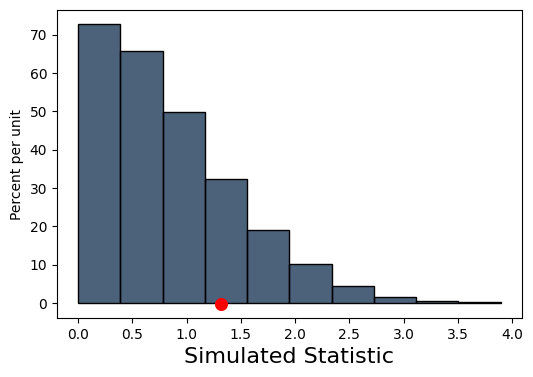

In [ ]:
from datascience import *
import matplotlib.pyplot as plt
import numpy as np

repetitions = 4000

simulated_statistics_ab = make_array()
for i in np.arange(repetitions):
    simulated_statistics_ab = np.append(simulated_statistics_ab, simulate_one_statistic())

# Do not change these lines
Table().with_columns('Simulated Statistic', simulated_statistics_ab).hist()
plt.scatter(observed_statistic_ab, -0.002, color='red', s=70);

%matplotlib inline
plt.show()

In [ ]:
simulated_statistics_ab

array([ 1.61858974,  0.50480769,  0.29647436, ...,  0.12820513,
        1.00160256,  2.46794872])

## Question 11.

Use the simulation to find an empirical approximation to the p-value. Assign `p_val` to the appropriate p-value from this simulation. Then, assign `conclusion` to either `null_hyp` or `alt_hyp`. (4 points)

Note: Assume that we use the 5% cutoff for the p-value.

In [ ]:
# These are variables provided for you to use.
null_hyp = 'The data are consistent with the null hypothesis.'
alt_hyp = 'The data support the alternative more than the null.'

p_val = np.mean(simulated_statistics_ab >= observed_statistic_ab)
conclusion = alt_hyp if p_val > 0.05 else null_hyp

p_val, conclusion # Do not change this line


(0.20849999999999999, 'The data support the alternative more than the null.')

# Test: Confidence Intervals

##Thai Restaurants in Berkeley

# Comparing Two Samples

Oswaldo and Varun are trying to see what the best Thai restaurant in Berkeley is. They survey 1,500 UC Berkeley students selected uniformly at random and ask each student what Thai restaurant is the best. (Note: This data is fabricated for the purposes of this homework.) The choices of Thai restaurants are Lucky House, Imm Thai, Thai Temple, and Thai Basil. After compiling the results, Oswaldo and Varun release the following percentages from their sample:

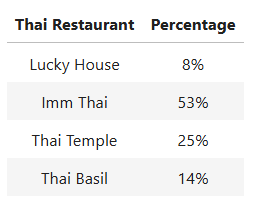

These percentages represent a uniform random sample of the population of UC Berkeley students. We will attempt to estimate the corresponding parameters, or the percentage of the votes that each restaurant will receive from the population (i.e. all UC Berkeley students). We will use confidence intervals to compute a range of values that reflects the uncertainty of our estimates.

The table votes contains the results of Oswaldo and Varun's survey.

In [ ]:
from datascience import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Just run this cell
votes = Table.read_table('votes.csv')
votes

Vote
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House
Lucky House


###Question 1.

Complete the function one_resampled_percentage below. It should return Imm Thai's percentage of votes after taking the original table (tbl) and performing one bootstrap sample of it. Reminder that a percentage is between 0 and 100. (9 Points)

Note: tbl will always be in the same format as votes.

Hint: Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? Be sure to use percentages, not proportions, for this question!

In [ ]:
def one_resampled_percentage(tbl):
    sample = tbl.sample()
    imm_thai_count = (sample.where('Vote', are.equal_to('Imm Thai'))).num_rows
    total_elements = (sample).num_rows
    return (imm_thai_count/total_elements) * 100

one_resampled_percentage(votes)

48.93333333333334

### Question 2.

Complete the percentages_in_resamples function such that it simulates and returns an array of 2022 elements, where each element represents a bootstrapped estimate of the percentage of voters who will vote for Imm Thai. You should use the one_resampled_percentage function you wrote above. (9 Points)

In [ ]:
def percentages_in_resamples():
    percentage_imm = make_array()
    for i in np.arange(1500):
        percentage_imm = np.append(percentage_imm, one_resampled_percentage(votes))
    return percentage_imm

In the following cell, we run the function you just defined, percentages_in_resamples, and create a histogram of the calculated statistic for the 2022 bootstrap estimates of the percentage of voters who voted for Imm Thai.

Note: This might take a few seconds to run.

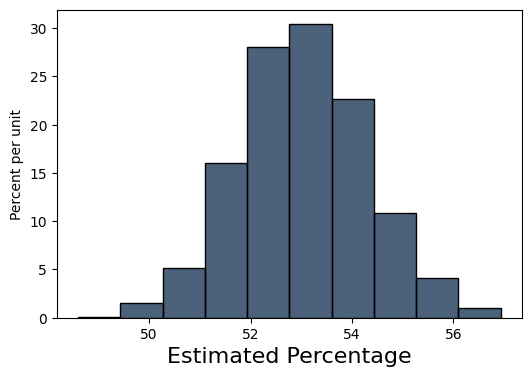

In [ ]:
resampled_percentages = percentages_in_resamples()
%matplotlib inline
Table().with_column('Estimated Percentage', resampled_percentages).hist("Estimated Percentage")

### Question 3.

Using the array resampled_percentages, find the values at the two edges of the middle 95% of the bootstrapped percentage estimates. Compute the lower and upper ends of the interval, named imm_lower_bound and imm_upper_bound respectively. (9 Points)

Hint: If you are stuck on this question, try looking over Chapter 13 of the textbook.

In [ ]:
imm_lower_bound = percentile(2.5, resampled_percentages)
imm_upper_bound = percentile(97.5, resampled_percentages)
print(f"Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [{imm_lower_bound:.2f}, {imm_upper_bound:.2f}]")

Bootstrapped 95% confidence interval for the percentage of Imm Thai voters in the population: [50.60, 55.60]


### Question 4.

The survey results seem to indicate that Imm Thai is beating all the other Thai restaurants among the voters. We would like to use confidence intervals to determine a range of likely values for Imm Thai's true lead over all the other restaurants combined. The calculation for Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined is:

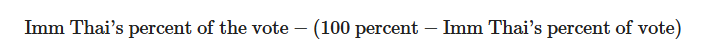

Define the function one_resampled_difference that returns exactly one value of Imm Thai's percentage lead over Lucky House, Thai Temple, and Thai Basil combined from one bootstrap sample of tbl. (9 Points)

Hint 1: Imm Thai's lead can be negative.

Hint 2: Given a table of votes, how can you figure out what percentage of the votes are for a certain restaurant? Be sure to use percentages, not proportions, for this question!

Note: If the skeleton code provided within the function is not helpful for you, feel free to approach the question using your own variables.

In [ ]:
def one_resampled_difference(tbl):
    bootstrap = one_resampled_percentage(tbl)
    imm_percentage = bootstrap - (100.0 - bootstrap)
    return imm_percentage

### Question 5.

Write a function called leads_in_resamples that returns an array of 2022 elements representing the bootstrapped estimates (the result of calling one_resampled_difference) of Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Afterwards, run the cell to plot a histogram of the resulting samples. (9 Points)

Hint: If you see an error involving NoneType, consider what components a function needs to have!

In [ ]:
def leads_in_resamples(tbl):
  leads = make_array()
  for i in np.arange(1500):
    leads = np.append(leads, one_resampled_difference(tbl))
  return leads

### Question 6.

Use the simulated data in sampled_leads from Question 1.5 to compute an approximate 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined. (9 Points)

In [ ]:
leads = leads_in_resamples(votes)
diff_lower_bound = percentile(2.5, leads)
diff_upper_bound = percentile(97.5, leads)
print("Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [{:f}%, {:f}%]".format(diff_lower_bound, diff_upper_bound))

Bootstrapped 95% confidence interval for Imm Thai's true lead over Lucky House, Thai Temple, and Thai Basil combined: [1.200000%, 10.933333%]


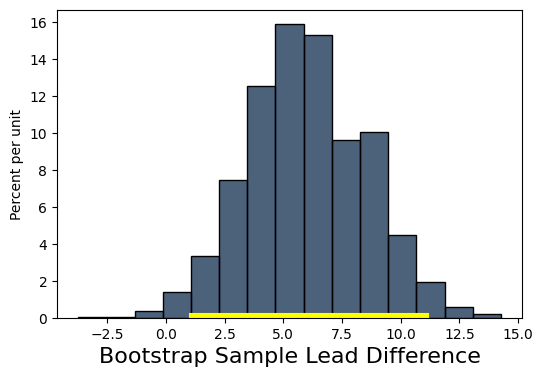

In [ ]:
resampled_medians = Table().with_columns(
    'Bootstrap Sample Lead Difference', leads
)
resampled_medians.hist(bins=15)
plt.plot([diff_lower_bound, diff_upper_bound], [0, 0], color='yellow', lw=8);

#Interpreting Confidence Intervals

The staff computed the following 95% confidence interval for the percentage of Imm Thai voters:

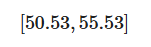

(Your answer may have been a bit different due to randomness; that doesn't mean it was wrong!)

## Question 1.

The staff also created 70%, 90%, and 99% confidence intervals from the same sample, but we forgot to label which confidence interval represented which percentages! First, match each confidence level (70%, 90%, 99%) with its corresponding interval in the cell below (e.g. __ % CI: [52.1, 54]
 replace the blank with one of the three confidence levels). Then, explain your thought process and how you came up with your answers. (10 Points)

The intervals are below:

* [50.03, 55.94]
* [52.1, 54]
* [50.97, 54.99]

In [ ]:
'''
70% confidence interval = [52.10, 54.00]
90% confidence interval = [50.97, 54.99]
99% confidence interval = [50.03, 55.94]
The lower the confidence level, the smaller the confidence interval.
'''

## Question 2.

Suppose we produced 6,000 new samples (each one a new/distinct uniform random sample of 1,500 students) from the population and created a 95% confidence interval from each one. Roughly how many of those 6,000 intervals do you expect will actually contain the true percentage of the population? (9 Points)

Assign your answer to true_percentage_intervals.

In [ ]:
true_percentage_intervals = 5700

Recall the second bootstrap confidence interval you created, which estimated Imm Thai's lead over Lucky House, Thai Temple, and Thai Basil combined. Among voters in the sample, Imm Thai's lead was 6%. The staff's 95% confidence interval for the true lead (in the population of all voters) was:

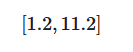

Suppose we are interested in testing a simple yes-or-no question:

> "Is the percentage of votes for Imm Thai equal to the percentage of votes for Lucky House, Thai Temple, and Thai Basil combined?"


Our null hypothesis is that the percentages are equal, or equivalently, that Imm Thai's lead is exactly 0. Our alternative hypothesis is that Imm Thai's lead is not equal to 0. In the questions below, don't compute any confidence interval yourself—use only the staff's 95% confidence interval.

## Question 3.

Say we use a 5% p-value cutoff. Do we reject the null, fail to reject the null, or are we unable to tell using the staff's confidence interval? (9 Points)

Assign cutoff_five_percent to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval

Hint: Consider the relationship between the p-value cutoff and confidence. If you're confused, take a look at this chapter of the textbook.

In [ ]:
cutoff_five_percent = 1

## Question 4.

What if, instead, we use a p-value cutoff of 1%? Do we reject the null, fail to reject the null, or are we unable to tell using our staff confidence interval? (9 Points)

Assign cutoff_one_percent to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval

In [ ]:
cutoff_one_percent = 3

## Question 5.

What if we use a p-value cutoff of 10%? Do we reject, fail to reject, or are we unable to tell using our confidence interval? (9 Points)

Assign cutoff_ten_percent to the number corresponding to the correct answer.

1. Reject the null / Data is consistent with the alternative hypothesis
2. Fail to reject the null / Data is consistent with the null hypothesis
3. Unable to tell using our staff confidence interval

In [ ]:
cutoff_ten_percent = 1

#Bootstrap

In [ ]:
from datascience import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
sf2019 = Table.read_table('san_francisco_2019.csv')

In [ ]:
sf2019

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Information Systems,IS Trainer-Journey,91332,0,40059,131391
Public Protection,Adult Probation,Information Systems,IS Engineer-Assistant,123241,0,49279,172520
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Senior,115715,0,46752,162468
Public Protection,Adult Probation,Information Systems,IS Business Analyst-Principal,159394,0,57312,216706
Public Protection,Adult Probation,Information Systems,IS Programmer Analyst,70035,0,28671,98706
Public Protection,Adult Probation,Information Systems,IS Project Director,175742,0,60830,236572
Public Protection,Adult Probation,Information Systems,IT Operations Support Admin IV,123840,0,49429,173269
Public Protection,Adult Probation,"Payroll, Billing & Accounting",Accountant III,111816,0,46319,158135
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Statistician,87725,0,38899,126624
Public Protection,Adult Probation,"Budget, Admn & Stats Analysis",Senior Administrative Analyst,116192,0,47651,163843


In [ ]:
sf2019.where('Job', 'Mayor')

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Mayor,Administrative & Mgmt (Unrep),Mayor,342974,0,98012,440987


In [ ]:
sf2019.sort('Total Compensation')

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
Public Protection,Adult Probation,Probation & Parole,Deputy Probation Officer,0,0,0,0
Public Protection,Fire Department,"Clerical, Secretarial & Steno",Senior Clerk Typist,0,0,0,0
Public Protection,Juvenile Court,Correction & Detention,"Counselor, Juvenile Hall PERS",0,0,0,0
Public Protection,Police,"Clerical, Secretarial & Steno",Clerk Typist,0,0,0,0
Public Protection,Sheriff,Correction & Detention,Deputy Sheriff,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Sub-Professional Engineering,StdntDsgn Train2/Arch/Eng/Plng,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Clerical, Secretarial & Steno",Executive Secretary 1,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,"Payroll, Billing & Accounting",Senior Account Clerk,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0
"Public Works, Transportation & Commerce",Airport Commission,Housekeeping & Laundry,Custodian,0,0,0,0


In [ ]:
sf2019 = sf2019.where('Salary', are.above(15000))

In [ ]:
sf2019.num_rows

37103

In [ ]:
sf2019 = sf2019.where('Salary', are.below(450000))

In [ ]:
sf2019.num_rows

37099

In [ ]:
%matplotlib inline

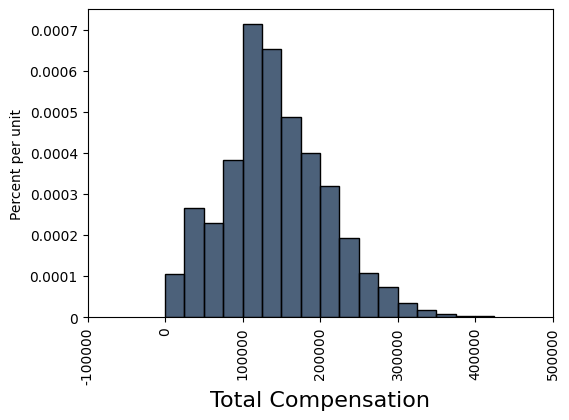

In [ ]:
sf_bins = np.arange(0, 450000, 25000)
sf2019.select('Total Compensation').hist(bins=sf_bins)

In [ ]:
sf2019.sort('Total Compensation', descending=True).show(10)

Organization Group,Department,Job Family,Job,Salary,Overtime,Benefits,Total Compensation
General Administration & Finance,Retirement Services,Administrative & Mgmt (Unrep),Chief Investment Officer,577633,0,146398,724031
General Administration & Finance,Retirement Services,Unassigned,Managing Director,483072,0,134879,617951
General Administration & Finance,Retirement Services,Unassigned,Managing Director,482649,0,134905,617554
General Administration & Finance,Retirement Services,Unassigned,Managing Director,451507,0,120276,571784
General Administration & Finance,Retirement Services,Unassigned,Managing Director,449378,0,120857,570235
Community Health,Public Health,Administrative & Mgmt (Unrep),"Physician Administrator, DPH",434966,0,119213,554179
Public Protection,Sheriff,Correction & Detention,Senior Deputy Sheriff,152153,315896,77275,545324
General Administration & Finance,Retirement Services,Management,Director,397392,0,108913,506305
Community Health,Public Health,Medical & Dental,Supervising Physician Spec,404701,0,99480,504181
Community Health,Public Health,Medical & Dental,Senior Physician Specialist,400992,0,97428,498421


In [ ]:
pop_median = percentile(50, sf2019.column('Total Compensation'))
pop_median

135742.0

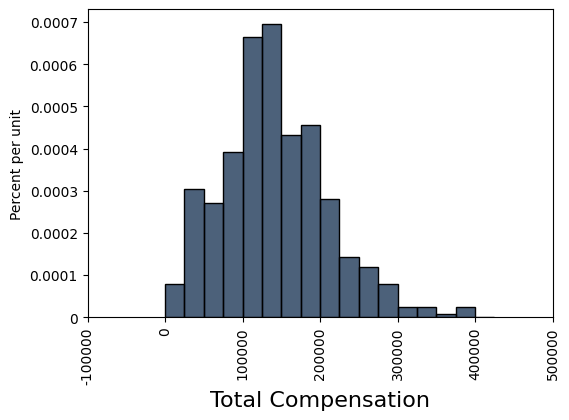

In [ ]:
our_sample = sf2019.sample(500, with_replacement=False)
our_sample.select('Total Compensation').hist(bins=sf_bins)

In [ ]:
est_median = percentile(50, our_sample.column('Total Compensation'))
est_median

135411.0

In [ ]:
resample_1 = our_sample.sample()

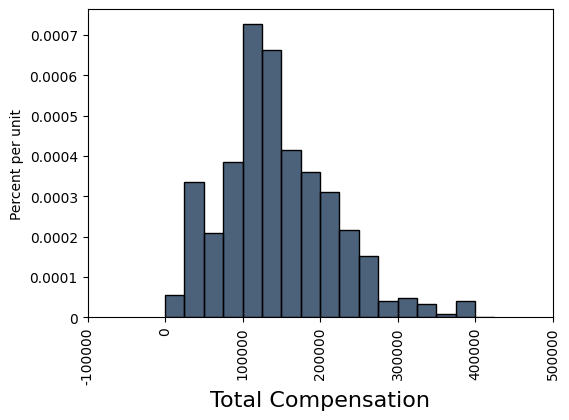

In [ ]:
resample_1.select('Total Compensation').hist(bins=sf_bins)

In [ ]:
resampled_median_1 = percentile(50, resample_1.column('Total Compensation'))
resampled_median_1


136555.0

In [ ]:
resample_2 = our_sample.sample()
resampled_median_2 = percentile(50, resample_2.column('Total Compensation'))
resampled_median_2

138919.0

In [ ]:
def one_bootstrap_median():
    resampled_table = our_sample.sample()
    bootstrapped_median = percentile(50, resampled_table.column('Total Compensation'))
    return bootstrapped_median

In [ ]:
one_bootstrap_median()

138137.0

In [ ]:
num_repetitions = 5000
bstrap_medians = make_array()
for i in np.arange(num_repetitions):
    bstrap_medians = np.append (bstrap_medians, one_bootstrap_median())

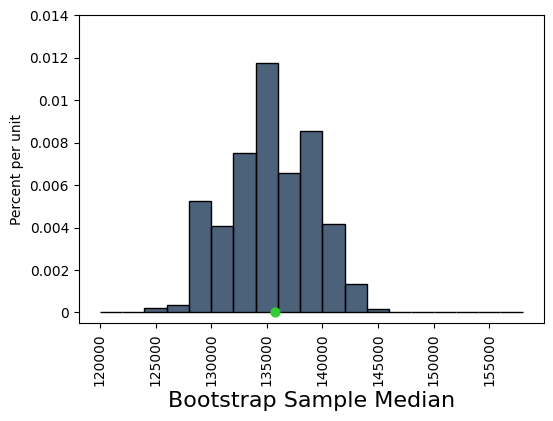

In [ ]:
resampled_medians = Table().with_column('Bootstrap Sample Median', bstrap_medians)
median_bins=np.arange(120000, 160000, 2000)
resampled_medians.hist(bins = median_bins)

# Plotting parameters; you can ignore this code
parameter_green = '#32CD32'
plt.ylim(-0.000005, 0.00014)
plt.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);

In [ ]:
left = percentile(2.5, bstrap_medians)
left

128741.0

In [ ]:
right = percentile(97.5, bstrap_medians)
right

142285.0

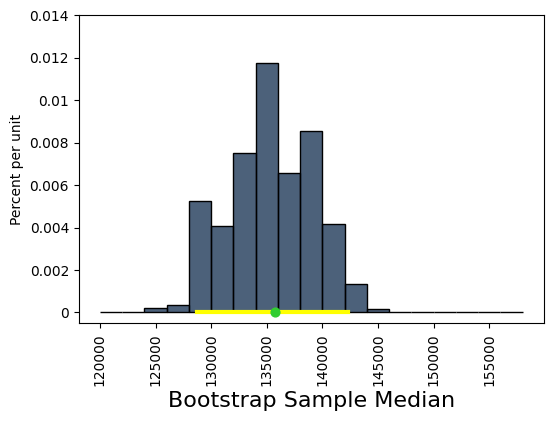

In [ ]:
resampled_medians.hist(bins = median_bins)

# Plotting parameters; you can ignore this code
plt.ylim(-0.000005, 0.00014)
plt.plot([left, right], [0, 0], color='yellow', lw=3, zorder=1)
plt.scatter(pop_median, 0, color=parameter_green, s=40, zorder=2);

In [ ]:
def bootstrap_median(original_sample, num_repetitions):
    medians = make_array()
    for i in np.arange(num_repetitions):
        new_bstrap_sample = original_sample.sample()
        new_bstrap_median = percentile(50, new_bstrap_sample.column('Total Compensation'))
        medians = np.append(medians, new_bstrap_median)
    return medians

In [ ]:
# THE BIG SIMULATION: This one takes several minutes.

# Generate 100 intervals and put the endpoints in the table intervals

left_ends = make_array()
right_ends = make_array()

for i in np.arange(100):
    original_sample = sf2019.sample(500, with_replacement=False)
    medians = bootstrap_median(original_sample, 5000)
    left_ends = np.append(left_ends, percentile(2.5, medians))
    right_ends = np.append(right_ends, percentile(97.5, medians))

intervals = Table().with_columns(
    'Left', left_ends,
    'Right', right_ends
)

In [ ]:
intervals.where(
    'Left', are.below(pop_median)).where(
    'Right', are.above(pop_median)).num_rows

Summary of Bootstrapping:

* Draw a large random sample from the population.

* Bootstrap your random sample and get an estimate from the new random sample.

* Repeat the above bootstrap step thousands of times, and get thousands of estimates.

* Pick off the “middle 95%” interval of all the estimates.

#Confidence Intervals

In [ ]:
from datascience import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
births = Table.read_table('baby.csv')

In [ ]:
births.show(3)

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True


In [ ]:
ratios = births.select('Birth Weight', 'Gestational Days').with_columns(
    'Ratio BW:GD', births.column('Birth Weight')/births.column('Gestational Days')
)

In [ ]:
ratios

Birth Weight,Gestational Days,Ratio BW:GD
120,284,0.422535
113,282,0.400709
128,279,0.458781
108,282,0.382979
136,286,0.475524
138,244,0.565574
132,245,0.538776
120,289,0.415225
143,299,0.478261
140,351,0.39886


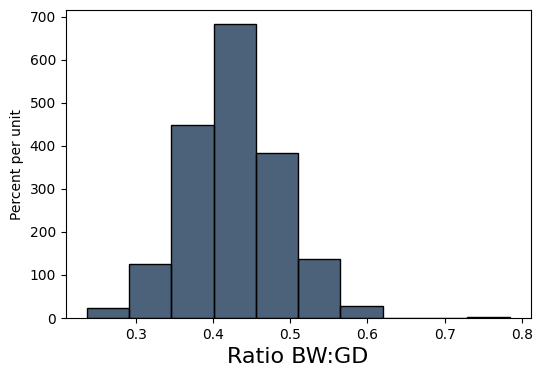

In [ ]:
%matplotlib inline
ratios.select('Ratio BW:GD').hist()

In [ ]:
ratios.sort('Ratio BW:GD', descending=True).take(0)

Birth Weight,Gestational Days,Ratio BW:GD
116,148,0.783784


In [ ]:
percentile(50, ratios.column(2))

0.42907801418439717

In [ ]:
def one_bootstrap_median():
    resample = ratios.sample()
    return percentile(50, resample.column('Ratio BW:GD'))

In [ ]:
one_bootstrap_median()

0.4290657439446367

In [ ]:
# Generate medians from 5000 bootstrap samples
num_repetitions = 5000
bstrap_medians = make_array()
for i in np.arange(num_repetitions):
    bstrap_medians = np.append(bstrap_medians, one_bootstrap_median())

In [ ]:
# Get the endpoints of the 95% confidence interval
left = percentile(2.5, bstrap_medians)
right = percentile(97.5, bstrap_medians)

make_array(left, right)

array([ 0.42545455,  0.43272727])

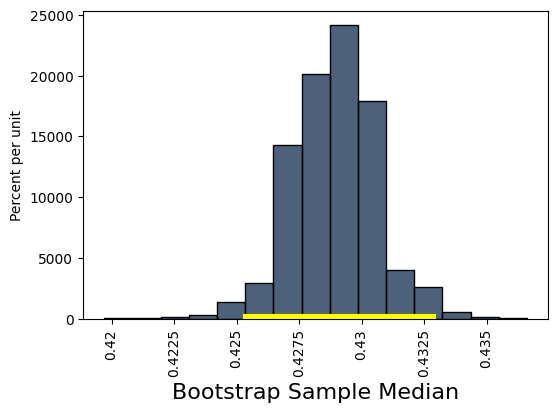

In [ ]:
resampled_medians = Table().with_columns(
    'Bootstrap Sample Median', bstrap_medians
)
resampled_medians.hist(bins=15)
plt.plot([left, right], [0, 0], color='yellow', lw=8);

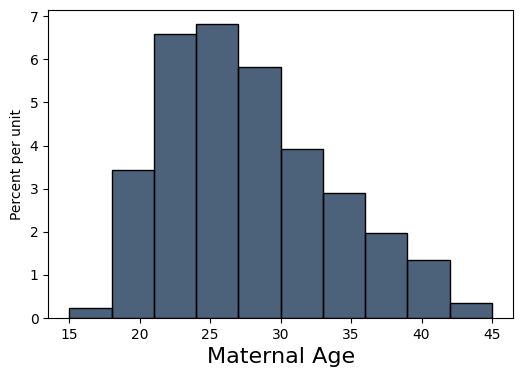

In [ ]:
births.select('Maternal Age').hist()

In [ ]:
np.average(births.column('Maternal Age'))

27.228279386712096

In [ ]:
def one_bootstrap_mean():
    resample = births.sample()
    return np.average(resample.column('Maternal Age'))

In [ ]:
# Generate means from 5000 bootstrap samples
num_repetitions = 5000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_mean())

In [ ]:
# Get the endpoints of the 95% confidence interval
left = percentile(2.5, bstrap_means)
right = percentile(97.5, bstrap_means)

make_array(left, right)

array([ 26.89608177,  27.56303237])

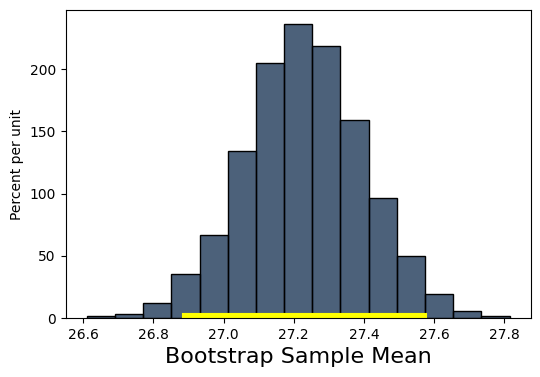

In [ ]:
resampled_means = Table().with_columns(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist(bins=15)
plt.plot([left, right], [0, 0], color='yellow', lw=8);

In [ ]:
#Fraction of maternal smokers compared to entire dataset
births.where('Maternal Smoker', are.equal_to(True)).num_rows / births.num_rows

0.3909710391822828

In [ ]:
#Another way to calculate fraction of maternal smokers
smoking = births.column('Maternal Smoker')
np.count_nonzero(smoking) / len(smoking)

0.3909710391822828

In [ ]:
def one_bootstrap_proportion():
    resample = births.sample()
    smoking = resample.column('Maternal Smoker')
    return np.count_nonzero(smoking) / len(smoking)

In [ ]:
# Generate proportions from 5000 bootstrap samples
bstrap_proportions = make_array()
num_repetitions = 5000
for i in np.arange(num_repetitions):
    bstrap_proportions = np.append(bstrap_proportions, one_bootstrap_proportion())

In [ ]:
# Get the endpoints of the 95% confidence interval
left = percentile(2.5, bstrap_proportions)
right = percentile(97.5, bstrap_proportions)

make_array(left, right)

array([ 0.36286201,  0.41908007])

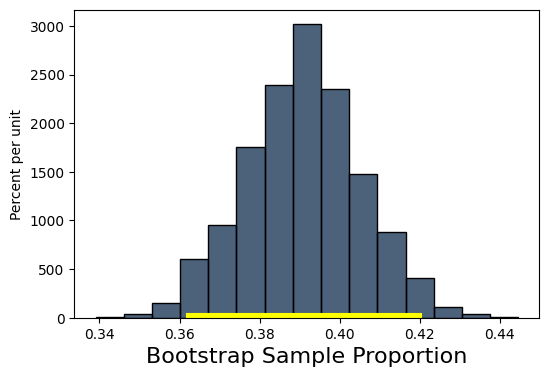

In [ ]:
resampled_proportions = Table().with_columns(
    'Bootstrap Sample Proportion', bstrap_proportions
)
resampled_proportions.hist(bins=15)
plt.plot([left, right], [0, 0], color='yellow', lw=8);

#Using a Confidence Interval to Test Hypotheses

In [ ]:
from datascience import *
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
hodgkins = Table.read_table('hodgkins.csv')

In [ ]:
hodgkins.show(3)

height,rad,chemo,base,month15
164,679,180,160.57,87.77
168,311,180,98.24,67.62
173,388,239,129.04,133.33


In [ ]:
hodgkins = hodgkins.with_columns(
    'drop', hodgkins.column('base') - hodgkins.column('month15')
)

In [ ]:
hodgkins

height,rad,chemo,base,month15,drop
164,679,180,160.57,87.77,72.8
168,311,180,98.24,67.62,30.62
173,388,239,129.04,133.33,-4.29
157,370,168,85.41,81.28,4.13
160,468,151,67.94,79.26,-11.32
170,341,96,150.51,80.97,69.54
163,453,134,129.88,69.24,60.64
175,529,264,87.45,56.48,30.97
185,392,240,149.84,106.99,42.85
178,479,216,92.24,73.43,18.81


In [ ]:
%matplotlib inline

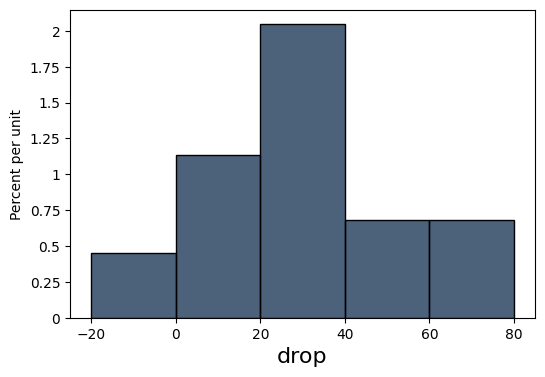

In [ ]:
hodgkins.select('drop').hist(bins=np.arange(-20, 81, 20))

In [ ]:
np.average(hodgkins.column('drop'))

28.615909090909096

In [ ]:
def one_bootstrap_mean():
    resample = hodgkins.sample()
    return np.average(resample.column('drop'))

In [ ]:
# Generate 10,000 bootstrap means
num_repetitions = 10000
bstrap_means = make_array()
for i in np.arange(num_repetitions):
    bstrap_means = np.append(bstrap_means, one_bootstrap_mean())

In [ ]:
# Get the endpoints of the 99% confidence interval
left = percentile(0.5, bstrap_means)
right = percentile(99.5, bstrap_means)

make_array(left, right)

array([ 17.19 ,  40.535])

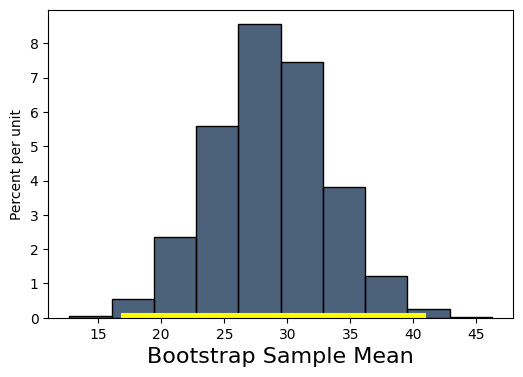

In [ ]:
resampled_means = Table().with_columns(
    'Bootstrap Sample Mean', bstrap_means
)
resampled_means.hist()
plt.plot([left, right], [0, 0], color='yellow', lw=8);

The 99% confidence interval for the average drop in the population goes from about 17 to about 40. The interval doesn’t contain 0. So we reject the null hypothesis.

But notice that we have done better than simply concluding that the average drop in the population isn’t 0. We have estimated how big the average drop is. That’s a more useful result than just saying, “It’s not 0.”